<a href="https://colab.research.google.com/github/jungeun1228/2026_08_OASIS_specificity-analysis/blob/main/Data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Prepare dfs with SMILES for individual compounds

In [ ]:
# Ewald et al (Table S1)
!pip install -q gdown

import gdown
import pandas as pd
import numpy as np

file_id = "1zOHDCxD5pXdm_K9QkrUmdnfzHVtAvOll"

gdown.download(
    id=file_id,
    output="ewald_tables1.xlsx",
    quiet=False
)

df_ewald = pd.read_excel("ewald_tables1.xlsx")
df_ewald.head()

Downloading...
From: https://drive.google.com/uc?id=1zOHDCxD5pXdm_K9QkrUmdnfzHVtAvOll
To: /content/ewald_tables1.xlsx
100%|██████████| 97.6k/97.6k [00:00<00:00, 51.3MB/s]


,Compound Name,OASIS_ID,Source code,Compound URL
0,Acetaminophen,OASIS001,s0618040,https://www.medchemexpress.com/acetaminophen.html
1,Theophylline,OASIS003,s0618842,https://www.medchemexpress.com/Theophylline.html
2,Ketoconazole,OASIS004,s0618878,https://www.medchemexpress.com/Ketoconazole.html
3,Tetracycline,OASIS005,s0617929,https://www.medchemexpress.com/Tetracycline.html
4,Coumarin,OASIS006,s0618484,https://www.medchemexpress.com/Coumarin.html


In [ ]:
# Some compounds have pseudonym...
df_ewald.tail(4)

,Compound Name,OASIS_ID,Source code,Compound URL
1081,Compound_1e0f84c9,NaN,NaN,NaN
1082,Compound_fdb8d1f5,NaN,NaN,NaN
1083,Compound_15eba834,NaN,NaN,NaN
1084,Compound_04264751,NaN,NaN,NaN


In [ ]:
# Count compounds with pseudonym
count_pseudonym = df_ewald['Compound Name'].str.startswith("Compound_", na=False).sum()
print(f"The number of compounds with pseudonym: {count_pseudonym} compounds")
# Remove the compounds with pseudonym
df_ewald_ref = df_ewald[~df_ewald["Compound Name"].str.startswith("Compound_", na=False)].copy()
print(f"The number of compounds after removing pseudonym compounds: {df_ewald_ref.shape[0]}")

The number of compounds with pseudonym: 119 compounds
The number of compounds after removing pseudonym compounds: 966


In [ ]:
# Import OASIS compound list (OASIS ID, SMILES, etc.)

file_id = "13P8itB6FUvLxluq1aw34dMkXqsZtPOkx"

gdown.download(
    id=file_id,
    output="OASIS_compound_list.csv",
    quiet=False
)

df_oasis = pd.read_csv("OASIS_compound_list.csv")
df_oasis.head()

Downloading...
From: https://drive.google.com/uc?id=13P8itB6FUvLxluq1aw34dMkXqsZtPOkx
To: /content/OASIS_compound_list.csv
100%|██████████| 577k/577k [00:00<00:00, 12.0MB/s]


,OASIS_ID,DTXSID,PREFERRED_NAME,DTXCID,CASRN,INCHIKEY,IUPAC_NAME,SMILES,INCHI_STRING,DILILIST_ID,DILIRANK2_ID,DRUGMATRIX_ID,FRAUNHOFER_ID,ICE_ID,TGGATES_ID,TOXREFDB_ID,Invivo_ranking,Purchased_Broad_Enamine,Purchased_Broad_Molport,Purchased_Broad_Medchemxpress
0,OASIS085,DTXSID2023270,Metformin,DTXCID803270,657-24-9,XZWYZXLIPXDOLR-UHFFFAOYSA-N,"N,N-Dimethyltriimidodicarbonic diamide",CN(C)C(=N)NC(N)=N,"InChI=1S/C4H11N5/c1-9(2)4(7)8-3(5)6/h1-2H3,(H5...",dilist_1110,NaN,NaN,NaN,NaN,tggates_81,NaN,2.0,Yes,No,Yes
1,OASIS676,DTXSID0046779,Darunavir,DTXCID8026779,206361-99-1,CJBJHOAVZSMMDJ-HEXNFIEUSA-N,"(3R,3aS,6aR)-Hexahydrofuro[2,3-b]furan-3-yl {(...",CC(C)CN(C[C@@H](O)[C@H](CC1=CC=CC=C1)NC(=O)O[C...,"InChI=1S/C27H37N3O7S/c1-18(2)15-30(38(33,34)21...",dilist_179,NaN,NaN,NaN,NaN,NaN,NaN,4.0,Yes,No,Yes
2,OASIS1250,DTXSID6046214,Adefovir,DTXCID4026214,106941-25-7,SUPKOOSCJHTBAH-UHFFFAOYSA-N,{[2-(6-Amino-9H-purin-9-yl)ethoxy]methyl}phosp...,NC1=NC=NC2=C1N=CN2CCOCP(O)(O)=O,InChI=1S/C8H12N5O4P/c9-7-6-8(11-3-10-7)13(4-12...,dilist_958,NaN,NaN,NaN,NaN,NaN,NaN,4.0,Yes,No,Yes
3,OASIS272,DTXSID7047279,CP-532623,DTXCID5027279,261947-38-0,TUPKOWFPVAXQFP-OFNKIYASSA-N,"Propan-2-yl (2R,4S)-4-(acetyl{[3,5-bis(trifluo...",CC[C@@H]1C[C@H](N(CC2=CC(=CC(=C2)C(F)(F)F)C(F)...,InChI=1S/C27H27F9N2O3/c1-5-20-12-23(21-11-17(2...,NaN,NaN,NaN,NaN,NaN,NaN,toxrefdb_159,1.0,No,No,Yes
4,OASIS1238,DTXSID6044012,Saquinavir,DTXCID4024012,127779-20-8,QWAXKHKRTORLEM-UGJKXSETSA-N,"N~1~-{(2S,3R)-4-[(3S,4aS,8aS)-3-(tert-Butylcar...",CC(C)(C)NC(=O)[C@@H]1C[C@@H]2CCCC[C@@H]2CN1C[C...,"InChI=1S/C38H50N6O5/c1-38(2,3)43-37(49)32-20-2...",dilist_130,NaN,NaN,NaN,NaN,NaN,NaN,4.0,No,No,Yes


In [ ]:
# Combine two dfs
df_combined = df_ewald_ref.drop(columns=df_ewald_ref.columns[3])

df_combined = df_combined.merge(df_oasis[["DTXSID", "CASRN","OASIS_ID", "SMILES"]],
                                on="OASIS_ID",
                                how="left")
df_combined.head()

,Compound Name,OASIS_ID,Source code,DTXSID,CASRN,SMILES
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1


In [ ]:
# count rows to check duplicates
print(f"before combination: {df_ewald_ref.shape[0]} rows")
print(f"after combination: {df_combined.shape[0]} rows")

before combination: 966 rows
after combination: 975 rows


In [ ]:
# Why do we have more rows after combining two dfs? Check duplicates
df_combined[df_combined.duplicated(keep=False)].sort_values("OASIS_ID")

,Compound Name,OASIS_ID,Source code,DTXSID,CASRN,SMILES
11,Sulfasalazine,OASIS018,s0618669,DTXSID0021256,599-79-1,OC(=O)C1=CC(=CC=C1O)N=NC1=CC=C(C=C1)S(=O)(=O)N...
12,Sulfasalazine,OASIS018,s0618669,DTXSID0021256,599-79-1,OC(=O)C1=CC(=CC=C1O)N=NC1=CC=C(C=C1)S(=O)(=O)N...
404,Peramivir,OASIS1596,s0618530,DTXSID10904727,330600-85-6,CCC(CC)[C@H](NC(C)=O)[C@@H]1[C@H](O)[C@H](C[C@...
405,Peramivir,OASIS1596,s0618530,DTXSID10904727,330600-85-6,CCC(CC)[C@H](NC(C)=O)[C@@H]1[C@H](O)[C@H](C[C@...
407,Titanocene dichloride,OASIS1600,s0617904,DTXSID3021354,1271-19-8,Cl[Ti]Cl.c1cccc1.c1cccc1
408,Titanocene dichloride,OASIS1600,s0617904,DTXSID3021354,1271-19-8,Cl[Ti]Cl.c1cccc1.c1cccc1
411,Ginkgo biloba extract,OASIS1612,s0618047,DTXSID8031366,90045-36-6,NaN
412,Ginkgo biloba extract,OASIS1612,s0618047,DTXSID8031366,90045-36-6,NaN
410,Ginkgo biloba extract,OASIS1612,s0618047,DTXSID8031366,90045-36-6,NaN
427,Indole-3-carbinol,OASIS1656,s0618607,DTXSID7031458,700-06-1,OCC1=CNC2=C1C=CC=C2


In [ ]:
# Do duplicates have the same info? compare with unique rows
df_combined[df_combined.duplicated()].sort_values("OASIS_ID")

,Compound Name,OASIS_ID,Source code,DTXSID,CASRN,SMILES
12,Sulfasalazine,OASIS018,s0618669,DTXSID0021256,599-79-1,OC(=O)C1=CC(=CC=C1O)N=NC1=CC=C(C=C1)S(=O)(=O)N...
405,Peramivir,OASIS1596,s0618530,DTXSID10904727,330600-85-6,CCC(CC)[C@H](NC(C)=O)[C@@H]1[C@H](O)[C@H](C[C@...
408,Titanocene dichloride,OASIS1600,s0617904,DTXSID3021354,1271-19-8,Cl[Ti]Cl.c1cccc1.c1cccc1
411,Ginkgo biloba extract,OASIS1612,s0618047,DTXSID8031366,90045-36-6,NaN
412,Ginkgo biloba extract,OASIS1612,s0618047,DTXSID8031366,90045-36-6,NaN
428,Indole-3-carbinol,OASIS1656,s0618607,DTXSID7031458,700-06-1,OCC1=CNC2=C1C=CC=C2
433,"N,N-Dimethyl-4-toluidine",OASIS1679,s0617988,DTXSID0021832,99-97-8,CN(C)C1=CC=C(C)C=C1
437,Myrcene,OASIS1691,s0618816,DTXSID6025692,123-35-3,CC(C)=CCCC(=C)C=C
470,Vasopressin,OASIS1751,s0618684,DTXSID201018727,11000-17-2,NaN


In [ ]:
# Drop duplicates and Keep only one row
df_combined = df_combined.drop_duplicates(keep="first")
print(f"after removing duplicates: {df_combined.shape[0]} rows")

after removing duplicates: 966 rows


In [ ]:
# Check if any compound has SMILES missing
df_combined[df_combined["SMILES"].isna()]

,Compound Name,OASIS_ID,Source code,DTXSID,CASRN,SMILES
79,Tannic acid,OASIS101,s0618885,DTXSID2026076,1401-55-4,NaN
99,Nystatin,OASIS1043,s0618041,DTXSID4040688,1400-61-9,NaN
258,Ivermectin,OASIS1337,s0618542,DTXSID7040235,70288-86-7,NaN
333,Bacitracin,OASIS1461,s0618949,DTXSID8045355,1405-87-4,NaN
409,Corn oil,OASIS1608,s0617874,DTXSID7021075,8001-30-7,NaN
410,Ginkgo biloba extract,OASIS1612,s0618047,DTXSID8031366,90045-36-6,NaN
469,Vasopressin,OASIS1751,s0618684,DTXSID201018727,11000-17-2,NaN
808,Simethicone,OASIS686,s0618032,DTXSID00904918,8050-81-5,NaN
952,Hydroxyethyl starch,OASIS959,s0617945,DTXSID3046829,9005-27-0,NaN


In [ ]:
# For chemicals above, SMILES were missing because: these are mixture of several chemicals, so single SMILES cannot be given
# Exclude from further analysis
df_combined = df_combined[~df_combined["SMILES"].isna()]
df_combined.shape[0]

957

In [ ]:
df_combined

,Compound Name,OASIS_ID,Source code,DTXSID,CASRN,SMILES
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1
...,...,...,...,...,...,...
970,Altretamine,OASIS993,s0618722,DTXSID4022579,645-05-6,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C
971,Ampicillin,OASIS994,s0617928,DTXSID4022602,69-53-4,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...
972,Amsacrine,OASIS995,s0618496,DTXSID4022604,51264-14-3,COC1=CC(NS(C)(=O)=O)=CC=C1NC1=C2C=CC=CC2=NC2=C...
973,Benoxaprofen,OASIS996,s0618038,DTXSID4022650,51234-28-7,CC(C(O)=O)C1=CC=C2OC(=NC2=C1)C1=CC=C(Cl)C=C1


#2. Combine with Speciation fraction data from PlayMolecule AcepKa
https://playmolecule.ai/tools/

- Predicted protonation states and their states probabilities at pH 7.4.
- Leveraged PlayMolecule’s AI assistant for post-processing result files and data organization. (combined individual states probabilities into speciation fractions for the neutral, negatively charged, positively charged, and zwitterionic forms)
- **Playmoledule AcepKa failed to process 65 chemicals**: Large moleculer weight; Contains metal/metalloid element; Contains dummy atom (*); Mixture with multiple fragments

In [ ]:
# Import speciation fraction at pH 7.4 for individual compounds

file_id = "1BY5iQpujKSGLTuHo5BrGuzMKmSB1CE5A"

gdown.download(
    id=file_id,
    output="Playmolecule_speciation_fraction.csv",
    quiet=False
)

df_speciation = pd.read_csv("Playmolecule_speciation_fraction.csv")
print(f"\n\nThe number of chemicals with speciation fraction information: {df_speciation.shape[0]} chemicals")
df_speciation.head()

Downloading...
From: https://drive.google.com/uc?id=1BY5iQpujKSGLTuHo5BrGuzMKmSB1CE5A
To: /content/Playmolecule_speciation_fraction.csv
100%|██████████| 93.9k/93.9k [00:00<00:00, 34.8MB/s]



The number of chemicals with speciation fraction information: 892 chemicals


,input_SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference
0,CO[C@H]1\C=C\O[C@@]2(C)OC3=C(C2=O)C2=C(C(O)=C3...,0.015893,0.663089,6.591978e-03,0.314426,PlayMolecule AcepKa
1,CS(O)(=O)=O.CC(C)(C)C1=CC(\C=C2/SC(=N)NC2=O)=C...,0.997603,0.002386,7.750000e-06,0.000004,PlayMolecule AcepKa
2,Cl.NC1=CC=C(C=C1)C(C1=CC=C(N)C=C1)=C1C=CC(=N)C=C1,0.764992,0.000000,2.350083e-01,0.000000,PlayMolecule AcepKa
3,O.O.O.Br.CN1[C@H]2C[C@@H](C[C@@H]1[C@H]1O[C@@H...,0.349736,0.000006,6.502572e-01,0.000000,PlayMolecule AcepKa
4,[H][C@@]12CC[C@](O)(C(=O)CO)[C@@]1(C)C[C@H](O)...,0.999941,0.000059,2.270000e-07,0.000000,PlayMolecule AcepKa


In [ ]:
df_all = df_speciation.copy()
df_all = df_combined.merge(df_speciation,
                           left_on="SMILES",
                           right_on="input_SMILES")

df_all = df_all.drop(columns=["input_SMILES"])
df_all

,Compound Name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000e+00,PlayMolecule AcepKa
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000e+00,PlayMolecule AcepKa
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000e+00,PlayMolecule AcepKa
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,4.207549e-01,PlayMolecule AcepKa
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000e+00,PlayMolecule AcepKa
...,...,...,...,...,...,...,...,...,...,...,...
887,Altretamine,OASIS993,s0618722,DTXSID4022579,645-05-6,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,0.986933,0.000000,1.306724e-02,0.000000e+00,PlayMolecule AcepKa
888,Ampicillin,OASIS994,s0617928,DTXSID4022602,69-53-4,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,0.000079,0.722973,1.390000e-06,2.769464e-01,PlayMolecule AcepKa
889,Amsacrine,OASIS995,s0618496,DTXSID4022604,51264-14-3,COC1=CC(NS(C)(=O)=O)=CC=C1NC1=C2C=CC=CC2=NC2=C...,0.092772,0.000096,9.071320e-01,0.000000e+00,PlayMolecule AcepKa
890,Benoxaprofen,OASIS996,s0618038,DTXSID4022650,51234-28-7,CC(C(O)=O)C1=CC=C2OC(=NC2=C1)C1=CC=C(Cl)C=C1,0.001968,0.998032,1.310000e-10,1.480000e-07,PlayMolecule AcepKa


# Import data from CompTox dashboard and extract logKow

In [ ]:
file_id = "1xie0rKc7QVRBU5DgntdmSyU-X49U6Hla"

gdown.download(
    id=file_id,
    output="Comptox_batch_search.xlsx",
    quiet=False
)

df_comptox = pd.read_excel("Comptox_batch_search.xlsx", sheet_name="Chemical Properties")
df_comptox

Downloading...
From: https://drive.google.com/uc?id=1xie0rKc7QVRBU5DgntdmSyU-X49U6Hla
To: /content/Comptox_batch_search.xlsx
100%|██████████| 2.05M/2.05M [00:00<00:00, 50.0MB/s]
/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION
0,DTXSID0033960,DTXCID5010773,experimental,Fraction Unbound in Human Plasma,0.236666663,Dimensionless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
1,DTXSID0033960,DTXCID5010773,experimental,LogKow: Octanol-Water,4.5,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
2,DTXSID0034308,DTXCID40810049,experimental,Ready Binary Biodegradability,1.0,Binary 0/1,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
3,DTXSID0034930,DTXCID8014930,experimental,Estrogen Receptor Agonist,0.0,Binary 0/1,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
4,DTXSID0034930,DTXCID8014930,experimental,Estrogen Receptor Antagonist,0.0,Binary 0/1,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
...,...,...,...,...,...,...,...,...
37322,DTXSID0021834,DTXCID201834,experimental,Bioconcentration Factor,5.1286138399136485,L/kg,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
37323,DTXSID0021834,DTXCID201834,experimental,Boiling Point,279.0,°C,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
37324,DTXSID0021834,DTXCID201834,experimental,Estrogen Receptor Agonist,0.0,Binary 0/1,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
37325,DTXSID0021834,DTXCID201834,experimental,Estrogen Receptor Antagonist,0.0,Binary 0/1,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...


In [ ]:
df_comptox = df_comptox[df_comptox["NAME"].astype(str).str.contains("LogKow", na=False)].copy()
df_comptox

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION
1,DTXSID0033960,DTXCID5010773,experimental,LogKow: Octanol-Water,4.5,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
9,DTXSID0034930,DTXCID8014930,experimental,LogKow: Octanol-Water,1.68,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
20,DTXSID0037653,DTXCID8017653,experimental,LogKow: Octanol-Water,-0.02,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
61,DTXSID0040129,DTXCID8020129,experimental,LogKow: Octanol-Water,-0.43,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
75,DTXSID0040676,DTXCID8020676,experimental,LogKow: Octanol-Water,1.91,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
...,...,...,...,...,...,...,...,...
37255,DTXSID0021125,DTXCID901125,experimental,LogKow: Octanol-Water,2.89,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
37272,DTXSID0021337,DTXCID401337,experimental,LogKow: Octanol-Water,2.47,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
37282,DTXSID0021339,DTXCID201339,experimental,LogKow: Octanol-Water,0.53,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
37296,DTXSID0021383,DTXCID901382,experimental,LogKow: Octanol-Water,2.5149999999999997,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...


In [ ]:
# df_comptox: duplicated rows?
df_comptox_duplicated = df_comptox[df_comptox["DTXSID"].duplicated(keep=False)].sort_values("DTXSID").copy()
df_comptox_duplicated

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION
2021,DTXSID0020074,DTXCID5074,predicted,LogKow: Octanol-Water,-1.1,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re..."
11643,DTXSID0020074,DTXCID5074,experimental,LogKow: Octanol-Water,-1.1,Log10 unitless,PhysPropNCCT,The PHYSPROP data sets are the publicly availa...
37095,DTXSID0020074,DTXCID5074,experimental,LogKow: Octanol-Water,-1.1,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
34403,DTXSID0020151,DTXCID40151,experimental,LogKow: Octanol-Water,1.96,Log10 unitless,PhysPropNCCT,The PHYSPROP data sets are the publicly availa...
37104,DTXSID0020151,DTXCID40151,experimental,LogKow: Octanol-Water,1.96,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
...,...,...,...,...,...,...,...,...
30628,DTXSID9048354,DTXCID0028329,experimental,LogKow: Octanol-Water,0.16,Log10 unitless,PhysPropNCCT,The PHYSPROP data sets are the publicly availa...
11003,DTXSID9048354,DTXCID0028329,experimental,LogKow: Octanol-Water,0.16,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
31159,DTXSID9073125,DTXCID0034352,experimental,LogKow: Octanol-Water,5.76,Log10 unitless,PhysPropNCCT,The PHYSPROP data sets are the publicly availa...
36789,DTXSID9073125,DTXCID0034352,predicted,LogKow: Octanol-Water,5.76,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re..."


In [ ]:
# df_comptox: unique rows?
df_comptox.drop_duplicates(subset="DTXSID", keep="first")

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION
1,DTXSID0033960,DTXCID5010773,experimental,LogKow: Octanol-Water,4.5,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
9,DTXSID0034930,DTXCID8014930,experimental,LogKow: Octanol-Water,1.68,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
20,DTXSID0037653,DTXCID8017653,experimental,LogKow: Octanol-Water,-0.02,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
61,DTXSID0040129,DTXCID8020129,experimental,LogKow: Octanol-Water,-0.43,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
75,DTXSID0040676,DTXCID8020676,experimental,LogKow: Octanol-Water,1.91,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
...,...,...,...,...,...,...,...,...
36652,DTXSID9048564,DTXCID2028193,predicted,LogKow: Octanol-Water,3.37,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re..."
36666,DTXSID9048566,DTXCID2028195,predicted,LogKow: Octanol-Water,0.76,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re..."
36680,DTXSID9048691,DTXCID5028617,predicted,LogKow: Octanol-Water,4.21,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re..."
36696,DTXSID9049035,DTXCID4028961,predicted,LogKow: Octanol-Water,4.53,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re..."


In [ ]:
# Check sources other than PhysPropNCCT and OPERA
pd.set_option("display.max_rows", None)

df_comptox_duplicated[~df_comptox_duplicated["SOURCE"].astype(str).str.contains("OPERA|PhysProp", case=False, na=False, regex=True)].copy()

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION
34440,DTXSID0020319,DTXCID20319,experimental,LogKow: Octanol-Water,2.9,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."
34478,DTXSID0020448,DTXCID60448,experimental,LogKow: Octanol-Water,1.99,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."
34509,DTXSID0020573,DTXCID80573,experimental,LogKow: Octanol-Water,3.86,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."
34599,DTXSID0021383,DTXCID901382,experimental,LogKow: Octanol-Water,2.61,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."
11656,DTXSID0021961,DTXCID101961,experimental,LogKow: Octanol-Water,3.18,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."
34672,DTXSID0021965,DTXCID701965,experimental,LogKow: Octanol-Water,3.97,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."
11658,DTXSID0022858,DTXCID502858,experimental,LogKow: Octanol-Water,2.1,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."
14481,DTXSID1020198,DTXCID30198,experimental,LogKow: Octanol-Water,2.1,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."
14482,DTXSID1020300,DTXCID30300,experimental,LogKow: Octanol-Water,2.24,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."
14484,DTXSID1020306,DTXCID10306,experimental,LogKow: Octanol-Water,1.97,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."


In [ ]:
pd.reset_option("display.max_rows")

In [ ]:
# Check data details for further process
# case 1
df_comptox[df_comptox['DTXSID'] == "DTXSID8022371"]

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION
9705,DTXSID8022371,DTXCID302371,experimental,LogKow: Octanol-Water,3.32,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
24562,DTXSID8022371,DTXCID302371,experimental,LogKow: Octanol-Water,3.32,Log10 unitless,PhysPropNCCT,The PHYSPROP data sets are the publicly availa...
24563,DTXSID8022371,DTXCID302371,experimental,LogKow: Octanol-Water,3.32,Log10 unitless,"Yalkowsky et al. Chemosphere 2002, 48, 487–509","Ran, Y.; He, Y.; Yang, G.; Johnson, J. L. H.; ..."
32440,DTXSID8022371,DTXCID302371,predicted,LogKow: Octanol-Water,3.32,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re..."


In [ ]:
# case 2
df_comptox[df_comptox['DTXSID'] == "DTXSID8031863"]

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION
10069,DTXSID8031863,DTXCID6011863,experimental,LogKow: Octanol-Water,3.535,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...
25915,DTXSID8031863,DTXCID6011863,experimental,LogKow: Octanol-Water,2.57,Log10 unitless,NCCT_Physchem,NCCT Collected PhysChem Data manually extracte...
25916,DTXSID8031863,DTXCID6011863,experimental,LogKow: Octanol-Water,4.5,Log10 unitless,"Rayne et al, J. Env. Sci. and Health Part A, (...",Sierra Rayne & Kaya Forest (2009) Perfluoroalk...
33380,DTXSID8031863,DTXCID6011863,predicted,LogKow: Octanol-Water,3.54,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re..."


In [ ]:
### Choose one logKow value for individual chemicals

df_comptox = df_comptox.copy()

# VALUE column into numeric
df_comptox["VALUE"] = pd.to_numeric(
    df_comptox["VALUE"],
    errors="coerce",
)
# Preprocessing SOURCE column
source = df_comptox["SOURCE"].fillna("").astype(str)

# [Selection criteria]
conditions = [

    # 1st: experimental values from PhysPropNCCT
    source.str.contains(
        "PhysPropNCCT",
        case=False,
        regex=False,
        na=False,
    ),

    # 2nd: experimental values from literature: all other sources except "OPERA, PhysPropNCCT, NCCT_Physchem" (NCCT_Physchem looks unreliable source)
    source.ne("")
    & ~source.str.contains(
        r"OPERA|PhysPropNCCT|NCCT_Physchem",
        case=False,
        regex=True,
        na=False,
    ),

    # 3rd: OPERA
    source.str.contains(
        "OPERA",
        case=False,
        regex=False,
        na=False,
    ),
]

# 각 행에 우선순위와 기본 DETAIL 부여
df_priority = df_comptox.assign(
    _priority=np.select(
        conditions,
        [1, 2, 3],
        default=4,
    ),
    _detail_base=np.select(
        conditions,
        ["PhysPropNCCT", "Literature", "OPERA"],
        default="Others",
    ),
    _original_order=np.arange(len(df_comptox)),
)

# 각 DTXSID의 최고 우선순위
df_priority["_best_priority"] = (
    df_priority
    .groupby("DTXSID")["_priority"]
    .transform("min")
)

# 각 DTXSID에서 최고 우선순위에 해당하는 행만 선택
df_best = df_priority.loc[
    df_priority["_priority"].eq(df_priority["_best_priority"])
].copy()


### Use median values when there are two values from the same source type

def join_values(series): # define function for combining sources
    """
    결측값과 빈 문자열을 제외하고,
    중복을 제거한 뒤 원래 등장 순서대로 '/'로 연결
    """
    values = (
        series.dropna()
        .astype(str)
        .str.strip()
    )

    values = values[values.ne("")]

    return "/".join(pd.unique(values))


def summarize_dtxsid(group):  #
    # 원래 행 순서를 유지
    group = group.sort_values("_original_order")

    # logKow가 중앙값 계산에 실제로 사용될 수 있는 행
    valid = group.loc[group["VALUE"].notna()].copy()

    # 대표 행: 기존의 다른 컬럼들을 유지하기 위한 첫 번째 행
    representative = group.iloc[0].copy()

    detail_base = group["_detail_base"].iloc[0]

    if len(valid) > 1:
        # 동일 최고 우선순위에서 유효한 logKow가 여러 개:
        # 중앙값 사용
        representative["VALUE"] = valid["VALUE"].median()

        # 중앙값 계산에 사용된 행들의 SOURCE와 DESCRIPTION 연결
        representative["SOURCE"] = join_values(valid["SOURCE"])
        representative["DESCRIPTION"] = join_values(valid["DESCRIPTION"])

        representative["DETAIL"] = f"median from {detail_base}"

    elif len(valid) == 1:
        # 유효한 logKow가 하나뿐인 경우
        selected = valid.iloc[0]

        # 해당 행을 대표 행으로 사용
        representative = selected.copy()
        representative["DETAIL"] = detail_base

    else:
        # 최고 우선순위 행은 있지만 logKow가 전부 결측인 경우
        representative["VALUE"] = np.nan
        representative["SOURCE"] = join_values(group["SOURCE"])
        representative["DESCRIPTION"] = join_values(group["DESCRIPTION"])
        representative["DETAIL"] = detail_base

    return representative


df_comptox_selected = (
    df_best
    .groupby("DTXSID", group_keys=False, sort=False)
    .apply(summarize_dtxsid)
    .reset_index(drop=True)
    .drop(
        columns=[
            "_priority",
            "_detail_base",
            "_original_order",
            "_best_priority",
        ],
        errors="ignore",
    )
)

/tmp/ipykernel_1557/3889760525.py:132: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_dtxsid)


In [ ]:
df_comptox_selected

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION,DETAIL
0,DTXSID001025928,DTXCID901510174,predicted,LogKow: Octanol-Water,2.89,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re...",OPERA
1,DTXSID001027855,DTXCID801513432,predicted,LogKow: Octanol-Water,0.71,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re...",OPERA
2,DTXSID001027893,DTXCID701513453,predicted,LogKow: Octanol-Water,3.08,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re...",OPERA
3,DTXSID001027936,DTXCID201513503,predicted,LogKow: Octanol-Water,5.47,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re...",OPERA
4,DTXSID001027948,DTXCID901513516,predicted,LogKow: Octanol-Water,0.51,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re...",OPERA
...,...,...,...,...,...,...,...,...,...
1427,DTXSID9048564,DTXCID2028193,predicted,LogKow: Octanol-Water,3.37,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re...",OPERA
1428,DTXSID9048566,DTXCID2028195,predicted,LogKow: Octanol-Water,0.76,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re...",OPERA
1429,DTXSID9048691,DTXCID5028617,predicted,LogKow: Octanol-Water,4.21,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re...",OPERA
1430,DTXSID9049035,DTXCID4028961,predicted,LogKow: Octanol-Water,4.53,Log10 unitless,OPERA2.8,"<a href=""https://github.com/kmansouri/OPERA/re...",OPERA


In [ ]:
# check if median values look reasonable
df_comptox_selected[df_comptox_selected['DETAIL'].str.contains("median from")]

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION,DETAIL
189,DTXSID7030432,DTXCID5010432,experimental,LogKow: Octanol-Water,-1.89,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...,median from OPERA
192,DTXSID9022940,DTXCID202940,experimental,LogKow: Octanol-Water,2.70,Log10 unitless,OPERA2.8,OPERA v2.8 (Open (Quantitative) Structure-acti...,median from OPERA
777,DTXSID7024164,DTXCID004164,experimental,LogKow: Octanol-Water,2.29,Log10 unitless,PhysPropNCCT,The PHYSPROP data sets are the publicly availa...,median from PhysPropNCCT
985,DTXSID8031865,DTXCID6011865,experimental,LogKow: Octanol-Water,3.60,Log10 unitless,"Danish_EPA_SCPFAS_Report_2015/Rayne et al, J. ...",Danish_EPA_Report: Short-chain Polyfluoroalkyl...,median from Literature


In [ ]:
# check if there is any row with different unit
df_comptox_selected[~df_comptox_selected['UNITS'].str.contains("Log10 unitless")]

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION,DETAIL


In [ ]:
df_comptox_selected[df_comptox_selected['SOURCE'].isna()]

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION,DETAIL


In [ ]:
df_comptox_selected[df_comptox_selected['DETAIL']=='Others'] # No values from NCCT_Physchem

,DTXSID,DTXCID,TYPE,NAME,VALUE,UNITS,SOURCE,DESCRIPTION,DETAIL


In [ ]:
df_comptox_selected["DETAIL"].value_counts()

,count
DETAIL,
OPERA,867
PhysPropNCCT,556
Literature,5
median from OPERA,2
median from PhysPropNCCT,1
median from Literature,1


# Combine logKow data with df_all

In [ ]:
df_all

,Compound Name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000e+00,PlayMolecule AcepKa
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000e+00,PlayMolecule AcepKa
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000e+00,PlayMolecule AcepKa
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,4.207549e-01,PlayMolecule AcepKa
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000e+00,PlayMolecule AcepKa
...,...,...,...,...,...,...,...,...,...,...,...
887,Altretamine,OASIS993,s0618722,DTXSID4022579,645-05-6,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,0.986933,0.000000,1.306724e-02,0.000000e+00,PlayMolecule AcepKa
888,Ampicillin,OASIS994,s0617928,DTXSID4022602,69-53-4,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,0.000079,0.722973,1.390000e-06,2.769464e-01,PlayMolecule AcepKa
889,Amsacrine,OASIS995,s0618496,DTXSID4022604,51264-14-3,COC1=CC(NS(C)(=O)=O)=CC=C1NC1=C2C=CC=CC2=NC2=C...,0.092772,0.000096,9.071320e-01,0.000000e+00,PlayMolecule AcepKa
890,Benoxaprofen,OASIS996,s0618038,DTXSID4022650,51234-28-7,CC(C(O)=O)C1=CC=C2OC(=NC2=C1)C1=CC=C(Cl)C=C1,0.001968,0.998032,1.310000e-10,1.480000e-07,PlayMolecule AcepKa


In [ ]:
df_all = df_all.copy()
df_all = df_all.merge(df_comptox_selected[["DTXSID", "VALUE", "SOURCE"]],
                      on="DTXSID",
                      how="left")
df_all = df_all.rename(columns={"Compound Name":"Compound_name",
                                "VALUE":"log Kow [L/L]",
                                "SOURCE":"Reference_log Kow"})
df_all

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000e+00,PlayMolecule AcepKa,0.46,PhysPropNCCT
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000e+00,PlayMolecule AcepKa,-0.02,PhysPropNCCT
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000e+00,PlayMolecule AcepKa,4.35,PhysPropNCCT
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,4.207549e-01,PlayMolecule AcepKa,-1.30,PhysPropNCCT
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000e+00,PlayMolecule AcepKa,1.39,PhysPropNCCT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,Altretamine,OASIS993,s0618722,DTXSID4022579,645-05-6,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,0.986933,0.000000,1.306724e-02,0.000000e+00,PlayMolecule AcepKa,2.73,PhysPropNCCT
888,Ampicillin,OASIS994,s0617928,DTXSID4022602,69-53-4,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,0.000079,0.722973,1.390000e-06,2.769464e-01,PlayMolecule AcepKa,1.35,PhysPropNCCT
889,Amsacrine,OASIS995,s0618496,DTXSID4022604,51264-14-3,COC1=CC(NS(C)(=O)=O)=CC=C1NC1=C2C=CC=CC2=NC2=C...,0.092772,0.000096,9.071320e-01,0.000000e+00,PlayMolecule AcepKa,2.72,OPERA2.8
890,Benoxaprofen,OASIS996,s0618038,DTXSID4022650,51234-28-7,CC(C(O)=O)C1=CC=C2OC(=NC2=C1)C1=CC=C(Cl)C=C1,0.001968,0.998032,1.310000e-10,1.480000e-07,PlayMolecule AcepKa,3.23,PhysPropNCCT


In [ ]:
# Check if any empty values
df_all[df_all["log Kow [L/L]"].isna()]

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow
815,Probucol,OASIS845,s0618830,DTXSID2045440,23288-49-5,CC(C)(SC1=CC(=C(O)C(=C1)C(C)(C)C)C(C)(C)C)SC1=...,0.999732,0.000268,0.0,0.0,PlayMolecule AcepKa,NaN,NaN


In [ ]:
# Fill in log Kow values from manual search
mask = df_all["Compound_name"].eq("Probucol")

df_all.loc[mask, "log Kow [L/L]"] = 11.3
df_all.loc[mask, "Reference_log Kow"] = "PubChem XLogP3"

In [ ]:
df_all[df_all["log Kow [L/L]"].isna()]

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow


# Check applicability domain

# Calculate Log Dlip/w (pH 7.4) from Kow QSAR
logDlipw7.4 = np.log10(NF * 10**(1.01 * logKow + 0.12) + (1 - NF) * 10**(1.01 * logKow + 0.12) / 10)
(NF: speciation fraction of neutral form)
- only neutral form: Kow QSAR
- other charged forms included: Kow QSAR (∆mw = 1)
- fixed @ -1 at logKow < -1 (Gobas 1988)

"Kow QSAR" refers to eq. 10 for KBSA/w and eq. 11 for Klip/w
"Kow QSAR (∆mw = 1)" for log Dlip/w (pH 7.4)  means  that the Klip/w  of the neutral species were predicted with the QSAR by Endo  and  corrected for speciation with a ∆mw of 1 (eq. 14)


In [ ]:
df_all

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000e+00,PlayMolecule AcepKa,0.46,PhysPropNCCT
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000e+00,PlayMolecule AcepKa,-0.02,PhysPropNCCT
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000e+00,PlayMolecule AcepKa,4.35,PhysPropNCCT
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,4.207549e-01,PlayMolecule AcepKa,-1.30,PhysPropNCCT
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000e+00,PlayMolecule AcepKa,1.39,PhysPropNCCT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,Altretamine,OASIS993,s0618722,DTXSID4022579,645-05-6,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,0.986933,0.000000,1.306724e-02,0.000000e+00,PlayMolecule AcepKa,2.73,PhysPropNCCT
888,Ampicillin,OASIS994,s0617928,DTXSID4022602,69-53-4,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,0.000079,0.722973,1.390000e-06,2.769464e-01,PlayMolecule AcepKa,1.35,PhysPropNCCT
889,Amsacrine,OASIS995,s0618496,DTXSID4022604,51264-14-3,COC1=CC(NS(C)(=O)=O)=CC=C1NC1=C2C=CC=CC2=NC2=C...,0.092772,0.000096,9.071320e-01,0.000000e+00,PlayMolecule AcepKa,2.72,OPERA2.8
890,Benoxaprofen,OASIS996,s0618038,DTXSID4022650,51234-28-7,CC(C(O)=O)C1=CC=C2OC(=NC2=C1)C1=CC=C(Cl)C=C1,0.001968,0.998032,1.310000e-10,1.480000e-07,PlayMolecule AcepKa,3.23,PhysPropNCCT


In [ ]:
import numpy as np
# apply Kow QSAR for logDlipw7.4
df_all["log Dlipw (pH 7.4)"] = np.log10(df_all["Neutral form (pH = 7.4)"] * 10**(1.01 * df_all["log Kow [L/L]"] + 0.12) + (1 - df_all["Neutral form (pH = 7.4)"]) * 10**(1.01 * df_all["log Kow [L/L]"] + 0.12) / 10)

# logDlipw7.4 fixed @ -1 at logKow < -1 (Gobas 1988)
mask = df_all["log Kow [L/L]"] < -1

df_all.loc[mask, "log Dlipw (pH 7.4)"] = -1

# add source for logDlipw7.4 values

df_all["Source"] = np.select([df_all["log Kow [L/L]"] < -1,
                              df_all["Neutral form (pH = 7.4)"] == 1,
                              df_all["Neutral form (pH = 7.4)"] < 1,],
                            ["fixed @ -1 at logKow < -1 (Gobas 1988)",
                            "Kow QSAR",
                            "Kow QSAR (∆mw = 1)",],
                            default=None)

df_all["Source"] = df_all["Source"].astype("string")
df_all

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow,log Dlipw (pH 7.4),Source
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000e+00,PlayMolecule AcepKa,0.46,PhysPropNCCT,0.580587,Kow QSAR (∆mw = 1)
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000e+00,PlayMolecule AcepKa,-0.02,PhysPropNCCT,0.081046,Kow QSAR (∆mw = 1)
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000e+00,PlayMolecule AcepKa,4.35,PhysPropNCCT,4.492217,Kow QSAR (∆mw = 1)
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,4.207549e-01,PlayMolecule AcepKa,-1.30,PhysPropNCCT,-1.000000,fixed @ -1 at logKow < -1 (Gobas 1988)
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000e+00,PlayMolecule AcepKa,1.39,PhysPropNCCT,1.523900,Kow QSAR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,Altretamine,OASIS993,s0618722,DTXSID4022579,645-05-6,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,0.986933,0.000000,1.306724e-02,0.000000e+00,PlayMolecule AcepKa,2.73,PhysPropNCCT,2.872162,Kow QSAR (∆mw = 1)
888,Ampicillin,OASIS994,s0617928,DTXSID4022602,69-53-4,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,0.000079,0.722973,1.390000e-06,2.769464e-01,PlayMolecule AcepKa,1.35,PhysPropNCCT,0.483810,Kow QSAR (∆mw = 1)
889,Amsacrine,OASIS995,s0618496,DTXSID4022604,51264-14-3,COC1=CC(NS(C)(=O)=O)=CC=C1NC1=C2C=CC=CC2=NC2=C...,0.092772,0.000096,9.071320e-01,0.000000e+00,PlayMolecule AcepKa,2.72,OPERA2.8,2.130824,Kow QSAR (∆mw = 1)
890,Benoxaprofen,OASIS996,s0618038,DTXSID4022650,51234-28-7,CC(C(O)=O)C1=CC=C2OC(=NC2=C1)C1=CC=C(Cl)C=C1,0.001968,0.998032,1.310000e-10,1.480000e-07,PlayMolecule AcepKa,3.23,PhysPropNCCT,2.389926,Kow QSAR (∆mw = 1)


In [ ]:
df_all["log Dlipw (pH 7.4)"].min()

-1.8695389806120482

In [ ]:
df_all[df_all["log Dlipw (pH 7.4)"] == df_all["log Dlipw (pH 7.4)"].min()]

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow,log Dlipw (pH 7.4),Source
199,Droxidopa,OASIS1251,s0618948,DTXSID6046422,23651-95-8,N[C@@H]([C@H](O)C1=CC(O)=C(O)C=C1)C(O)=O,0.000067,0.075829,0.000004,0.9241,PlayMolecule AcepKa,-0.98,OPERA2.8,-1.869539,Kow QSAR (∆mw = 1)


In [ ]:
df_all["log Dlipw (pH 7.4)"].max()

11.532895290661125

In [ ]:
df_all[df_all["log Dlipw (pH 7.4)"] > 8 ]

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow,log Dlipw (pH 7.4),Source
111,Vitamin D2,OASIS1079,s0618042,DTXSID5020233,50-14-6,[H][C@@]1(CC[C@@]2([H])\C(CCC[C@]12C)=C\C=C1\C...,1.000000,3.400000e-08,0.000000e+00,0.0,PlayMolecule AcepKa,8.38,OPERA2.8,8.583800,Kow QSAR (∆mw = 1)
205,Teprenone,OASIS1266,s0618769,DTXSID6048620,6809-52-5,CC(C)=CCC\C(C)=C\CC\C(C)=C\CCC(C)=CCCC(C)=O,0.999996,1.390000e-07,3.530000e-06,0.0,PlayMolecule AcepKa,8.23,OPERA2.8,8.432299,Kow QSAR (∆mw = 1)
228,Nandrolone decanoate,OASIS1315,s0618027,DTXSID7023352,360-70-3,CCCCCCCCCC(=O)O[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O...,0.999945,5.320000e-05,2.240000e-06,0.0,PlayMolecule AcepKa,8.42,OPERA2.8,8.624178,Kow QSAR (∆mw = 1)
289,Vitamin K1,OASIS1431,s0618670,DTXSID8023472,84-80-0,CC(C)CCC[C@@H](C)CCC[C@@H](C)CCC\C(C)=C\CC1=C(...,0.998469,1.530543e-03,5.160000e-07,0.0,PlayMolecule AcepKa,9.44,OPERA2.8,9.653801,Kow QSAR (∆mw = 1)
402,Calcifediol,OASIS1717,s0618022,DTXSID0022721,19356-17-3,[H][C@@]1(CC[C@@]2([H])\C(CCC[C@]12C)=C\C=C1\C...,1.000000,3.410000e-08,0.000000e+00,0.0,PlayMolecule AcepKa,8.13,OPERA2.8,8.331300,Kow QSAR (∆mw = 1)
703,Alfacalcidol,OASIS610,s0617935,DTXSID0022569,41294-56-8,[H][C@@]1(CC[C@@]2([H])\C(CCC[C@]12C)=C\C=C1\C...,1.000000,4.690000e-08,0.000000e+00,0.0,PlayMolecule AcepKa,8.15,OPERA2.8,8.351500,Kow QSAR (∆mw = 1)
815,Probucol,OASIS845,s0618830,DTXSID2045440,23288-49-5,CC(C)(SC1=CC(=C(O)C(=C1)C(C)(C)C)C(C)(C)C)SC1=...,0.999732,2.678590e-04,0.000000e+00,0.0,PlayMolecule AcepKa,11.30,PubChem XLogP3,11.532895,Kow QSAR (∆mw = 1)


# Calculate baseline toxicity from Baseline toxicity QSAR (a generalized version for adherent human cell lines)
```np.log10(1/IC10baseline) = 1.23 + 4.97 * (1- np.exp(-0.236*logDlipw))```

In [ ]:
df_all["log(1/IC10,baseline)"] = 1.23 + 4.97 * (1- np.exp(-0.236*df_all["log Dlipw (pH 7.4)"]))
df_all
# unit of IC10baseline: M

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow,log Dlipw (pH 7.4),Source,"log(1/IC10,baseline)"
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000e+00,PlayMolecule AcepKa,0.46,PhysPropNCCT,0.580587,Kow QSAR (∆mw = 1),1.866388
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000e+00,PlayMolecule AcepKa,-0.02,PhysPropNCCT,0.081046,Kow QSAR (∆mw = 1),1.324157
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000e+00,PlayMolecule AcepKa,4.35,PhysPropNCCT,4.492217,Kow QSAR (∆mw = 1),4.478396
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,4.207549e-01,PlayMolecule AcepKa,-1.30,PhysPropNCCT,-1.000000,fixed @ -1 at logKow < -1 (Gobas 1988),-0.092886
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000e+00,PlayMolecule AcepKa,1.39,PhysPropNCCT,1.523900,Kow QSAR,2.731302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,Altretamine,OASIS993,s0618722,DTXSID4022579,645-05-6,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,0.986933,0.000000,1.306724e-02,0.000000e+00,PlayMolecule AcepKa,2.73,PhysPropNCCT,2.872162,Kow QSAR (∆mw = 1),3.676645
888,Ampicillin,OASIS994,s0617928,DTXSID4022602,69-53-4,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,0.000079,0.722973,1.390000e-06,2.769464e-01,PlayMolecule AcepKa,1.35,PhysPropNCCT,0.483810,Kow QSAR (∆mw = 1),1.766273
889,Amsacrine,OASIS995,s0618496,DTXSID4022604,51264-14-3,COC1=CC(NS(C)(=O)=O)=CC=C1NC1=C2C=CC=CC2=NC2=C...,0.092772,0.000096,9.071320e-01,0.000000e+00,PlayMolecule AcepKa,2.72,OPERA2.8,2.130824,Kow QSAR (∆mw = 1),3.194195
890,Benoxaprofen,OASIS996,s0618038,DTXSID4022650,51234-28-7,CC(C(O)=O)C1=CC=C2OC(=NC2=C1)C1=CC=C(Cl)C=C1,0.001968,0.998032,1.310000e-10,1.480000e-07,PlayMolecule AcepKa,3.23,PhysPropNCCT,2.389926,Kow QSAR (∆mw = 1),3.372488


# Import Point of Departure (PoD) values from Cell painting assay (Ewald et al., 2026; Table S3)

In [ ]:
file_id = "135s-ieNvNwjaqOiBmdpvv9vdrpKdIJKp"

gdown.download(
    id=file_id,
    output="Cellpainting_POD.xlsx",
    quiet=False
)

df_cp_pod = pd.read_excel("Cellpainting_POD.xlsx")
df_cp_pod.head(30)

Downloading...
From: https://drive.google.com/uc?id=135s-ieNvNwjaqOiBmdpvv9vdrpKdIJKp
To: /content/Cellpainting_POD.xlsx
100%|██████████| 818k/818k [00:00<00:00, 120MB/s]


,OASIS_ID,Cell_representation,Compound_name,Assay_Endpoint,POD_um,POD_um_l,POD_um_u,Bioactivity_POD
0,OASIS1758,CellProfiler,Omadacycline,Cytoplasm_AreaShape,64.795643,62.932566,66.604753,False
1,OASIS1758,CellProfiler,Omadacycline,Cytoplasm_Mito,51.118303,47.333805,54.894826,True
2,OASIS557,CellProfiler,Fluazinam,Cells_AGP,4.660165,4.187263,5.104732,False
3,OASIS557,CellProfiler,Fluazinam,Cells_AreaShape,15.771461,15.573828,15.959585,False
4,OASIS557,CellProfiler,Fluazinam,Cells_DNA,0.148563,0.135881,0.163199,False
5,OASIS557,CellProfiler,Fluazinam,Cells_ER,1.433934,1.229386,1.667878,False
6,OASIS557,CellProfiler,Fluazinam,Cells_Mito,6.691160,5.812940,7.467657,False
7,OASIS557,CellProfiler,Fluazinam,Cells_RNA,15.457224,15.232958,15.665893,False
8,OASIS557,CellProfiler,Fluazinam,Cytoplasm_AGP,0.109622,0.098533,0.122664,True
9,OASIS557,CellProfiler,Fluazinam,Cytoplasm_AreaShape,2.344551,2.225842,2.462049,False


In [ ]:
df_cp_pod = df_cp_pod[~df_cp_pod['Compound_name'].str.startswith('Compound_', na=False)].copy()

In [ ]:
df_cp_pod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9668 entries, 0 to 10933
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OASIS_ID             9668 non-null   object 
 1   Cell_representation  9668 non-null   object 
 2   Compound_name        9668 non-null   object 
 3   Assay_Endpoint       9668 non-null   object 
 4   POD_um               9668 non-null   float64
 5   POD_um_l             9668 non-null   float64
 6   POD_um_u             9668 non-null   float64
 7   Bioactivity_POD      9668 non-null   bool   
dtypes: bool(1), float64(3), object(4)
memory usage: 613.7+ KB


In [ ]:
df_cp_pod["Cell_representation"].unique()

array(['CellProfiler', 'DINO', 'CP-CNN'], dtype=object)

In [ ]:
print(df_cp_pod["Assay_Endpoint"].nunique())
df_cp_pod["Assay_Endpoint"].unique()

25


array(['Cytoplasm_AreaShape', 'Cytoplasm_Mito', 'Cells_AGP',
       'Cells_AreaShape', 'Cells_DNA', 'Cells_ER', 'Cells_Mito',
       'Cells_RNA', 'Cytoplasm_AGP', 'Cytoplasm_DNA', 'Nuclei_AGP',
       'Nuclei_AreaShape', 'Nuclei_DNA', 'Nuclei_ER', 'Nuclei_Mito',
       'Cytoplasm_ER', 'Cytoplasm_RNA', 'Nuclei_RNA', 'gmd', 'AGP',
       'Mito', 'Brightfield', 'DNA', 'ER', 'RNA'], dtype=object)

In [ ]:
# 1. Assay endpoint for CellProfiler
print(df_cp_pod[df_cp_pod['Cell_representation'] == "CellProfiler"]["Assay_Endpoint"].nunique())
df_cp_pod[df_cp_pod['Cell_representation'] == "CellProfiler"]["Assay_Endpoint"].unique()

19


array(['Cytoplasm_AreaShape', 'Cytoplasm_Mito', 'Cells_AGP',
       'Cells_AreaShape', 'Cells_DNA', 'Cells_ER', 'Cells_Mito',
       'Cells_RNA', 'Cytoplasm_AGP', 'Cytoplasm_DNA', 'Nuclei_AGP',
       'Nuclei_AreaShape', 'Nuclei_DNA', 'Nuclei_ER', 'Nuclei_Mito',
       'Cytoplasm_ER', 'Cytoplasm_RNA', 'Nuclei_RNA', 'gmd'], dtype=object)

In [ ]:
# 2. Assay endpoint for CP-CNN: only global MD
print(df_cp_pod[df_cp_pod['Cell_representation'] == "CP-CNN"]["Assay_Endpoint"].nunique())
df_cp_pod[df_cp_pod['Cell_representation'] == "CP-CNN"]["Assay_Endpoint"].unique()

1


array(['gmd'], dtype=object)

In [ ]:
# 3. Assay endpoint for DINO: 6 channels and global MD
print(df_cp_pod[df_cp_pod['Cell_representation'] == "DINO"]["Assay_Endpoint"].nunique())
df_cp_pod[df_cp_pod['Cell_representation'] == "DINO"]["Assay_Endpoint"].unique()

7


array(['AGP', 'Mito', 'Brightfield', 'DNA', 'ER', 'gmd', 'RNA'],
      dtype=object)

### Take only min POD values from each cell representation (CellProfiler, CNN, DINO): Bioactivity_POD = True

In [ ]:
# Check if Bioactivity_POD means min POD for each cell representation
df_cp_pod['Min'] = (
    df_cp_pod['POD_um']
    == df_cp_pod.groupby(
        ['Cell_representation', 'OASIS_ID']
    )['POD_um'].transform('min')
)

df_cp_pod['Min_Bioactivity_match'] = (
    df_cp_pod['Min'] == df_cp_pod['Bioactivity_POD']
)

In [ ]:
print("df_cp_pod shape:", df_cp_pod.shape)
print("Min_Bioactivity_match = True:", df_cp_pod["Min_Bioactivity_match"].sum())
df_cp_pod.head(5)

df_cp_pod shape: (9668, 10)
Min_Bioactivity_match = True: 9668


,OASIS_ID,Cell_representation,Compound_name,Assay_Endpoint,POD_um,POD_um_l,POD_um_u,Bioactivity_POD,Min,Min_Bioactivity_match
0,OASIS1758,CellProfiler,Omadacycline,Cytoplasm_AreaShape,64.795643,62.932566,66.604753,False,False,True
1,OASIS1758,CellProfiler,Omadacycline,Cytoplasm_Mito,51.118303,47.333805,54.894826,True,True,True
2,OASIS557,CellProfiler,Fluazinam,Cells_AGP,4.660165,4.187263,5.104732,False,False,True
3,OASIS557,CellProfiler,Fluazinam,Cells_AreaShape,15.771461,15.573828,15.959585,False,False,True
4,OASIS557,CellProfiler,Fluazinam,Cells_DNA,0.148563,0.135881,0.163199,False,False,True


In [ ]:
# 1. Bioactivity_POD == True
df_true = df_cp_pod[
    df_cp_pod["Bioactivity_POD"] == True
].copy()

# 2. POD_um
pod_wide = df_true.pivot(
    index="OASIS_ID",
    columns="Cell_representation",
    values="POD_um"
)

pod_wide.columns = [
    f"POD_{col} (um)" for col in pod_wide.columns
]

# 3. Assay_Endpoint
assay_wide = df_true.pivot(
    index="OASIS_ID",
    columns="Cell_representation",
    values="Assay_Endpoint"
)

assay_wide.columns = [
    f"Assay_Endpoint_{col}" for col in assay_wide.columns
]

# 4. combine assay + pod
pod_assay_wide = pd.concat(
    [assay_wide, pod_wide],
    axis=1
).reset_index()

# 5. order columns
cell_order = ["CellProfiler", "CP-CNN", "DINO"]

ordered_cols = ["OASIS_ID"]

for cell in cell_order:
    ordered_cols += [
        f"Assay_Endpoint_{cell}",
        f"POD_{cell} (um)"
    ]

pod_assay_wide = pod_assay_wide.reindex(columns=ordered_cols)

# 6. merge into df_all
df_all = df_all.merge(
    pod_assay_wide,
    on="OASIS_ID",
    how="left"
)

In [ ]:
df_all

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),...,Reference_log Kow,log Dlipw (pH 7.4),Source,"log(1/IC10,baseline)",Assay_Endpoint_CellProfiler,POD_CellProfiler (um),Assay_Endpoint_CP-CNN,POD_CP-CNN (um),Assay_Endpoint_DINO,POD_DINO (um)
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000e+00,...,PhysPropNCCT,0.580587,Kow QSAR (∆mw = 1),1.866388,NaN,NaN,NaN,NaN,NaN,NaN
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000e+00,...,PhysPropNCCT,0.081046,Kow QSAR (∆mw = 1),1.324157,Nuclei_AGP,95.911135,NaN,NaN,NaN,NaN
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000e+00,...,PhysPropNCCT,4.492217,Kow QSAR (∆mw = 1),4.478396,Cytoplasm_RNA,3.282117,gmd,13.245321,Mito,12.282116
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,4.207549e-01,...,PhysPropNCCT,-1.000000,fixed @ -1 at logKow < -1 (Gobas 1988),-0.092886,NaN,NaN,gmd,98.768244,Brightfield,30.293853
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000e+00,...,PhysPropNCCT,1.523900,Kow QSAR,2.731302,Nuclei_ER,99.289088,gmd,41.276806,gmd,21.425531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,Altretamine,OASIS993,s0618722,DTXSID4022579,645-05-6,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,0.986933,0.000000,1.306724e-02,0.000000e+00,...,PhysPropNCCT,2.872162,Kow QSAR (∆mw = 1),3.676645,NaN,NaN,NaN,NaN,NaN,NaN
888,Ampicillin,OASIS994,s0617928,DTXSID4022602,69-53-4,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,0.000079,0.722973,1.390000e-06,2.769464e-01,...,PhysPropNCCT,0.483810,Kow QSAR (∆mw = 1),1.766273,NaN,NaN,NaN,NaN,NaN,NaN
889,Amsacrine,OASIS995,s0618496,DTXSID4022604,51264-14-3,COC1=CC(NS(C)(=O)=O)=CC=C1NC1=C2C=CC=CC2=NC2=C...,0.092772,0.000096,9.071320e-01,0.000000e+00,...,OPERA2.8,2.130824,Kow QSAR (∆mw = 1),3.194195,Cytoplasm_AGP,0.110672,gmd,13.491740,RNA,11.687511
890,Benoxaprofen,OASIS996,s0618038,DTXSID4022650,51234-28-7,CC(C(O)=O)C1=CC=C2OC(=NC2=C1)C1=CC=C(Cl)C=C1,0.001968,0.998032,1.310000e-10,1.480000e-07,...,PhysPropNCCT,2.389926,Kow QSAR (∆mw = 1),3.372488,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# compounds in both df_all (with speciation information) & df_cp_pod (POD from cell painting)
print("[CellProfiler] Rows with POD values:", df_all["POD_CellProfiler (um)"].notna().sum())
print("[CP-CNN] Rows with POD values:", df_all["POD_CP-CNN (um)"].notna().sum())
print("[DINO] Rows with POD values:", df_all["POD_DINO (um)"].notna().sum())

[CellProfiler] Rows with POD values: 478
[CP-CNN] Rows with POD values: 432
[DINO] Rows with POD values: 519


# Import Point of Departure (PoD) values from cytotoxicity assay (Ewald et al., 2026; Table S2)

In [ ]:
file_id = "1w5ttIhwE60WUBV27JezE8Z2-WMqOEARk"

gdown.download(
    id=file_id,
    output="Cytotoxicity_POD.xlsx",
    quiet=False
)

df_cytotox_pod = pd.read_excel("Cytotoxicity_POD.xlsx")
df_cytotox_pod

Downloading...
From: https://drive.google.com/uc?id=1w5ttIhwE60WUBV27JezE8Z2-WMqOEARk
To: /content/Cytotoxicity_POD.xlsx
100%|██████████| 65.5k/65.5k [00:00<00:00, 53.4MB/s]


,OASIS_ID,Assay,Compound_name,POD_um,POD_um_l,POD_um_u
0,OASIS007,MT,Nitrofurazone,4.544274,4.344033,4.747511
1,OASIS188,MT,Maropitant,21.179257,20.836759,21.514168
2,OASIS1788,MT,Nifurtimox,24.506731,23.605215,25.434312
3,NaN,MT,Compound_e48ed218,0.024158,0.023892,0.024423
4,OASIS1455,MT,Gefitinib,12.471706,12.221362,12.717598
...,...,...,...,...,...,...
791,OASIS1823,LDH,Palbociclib,54.241545,49.456238,59.416972
792,OASIS1304,LDH,Fluoxetine,65.154027,63.719538,66.587828
793,OASIS093,LDH,Clomipramine,75.287280,73.105596,77.474702
794,OASIS1825,LDH,Osimertinib,25.228887,23.678581,26.844688


In [ ]:
df_cytotox_pod = df_cytotox_pod[~df_cytotox_pod['Compound_name'].str.startswith('Compound_', na=False)].copy()

In [ ]:
df_cytotox_pod

,OASIS_ID,Assay,Compound_name,POD_um,POD_um_l,POD_um_u
0,OASIS007,MT,Nitrofurazone,4.544274,4.344033,4.747511
1,OASIS188,MT,Maropitant,21.179257,20.836759,21.514168
2,OASIS1788,MT,Nifurtimox,24.506731,23.605215,25.434312
4,OASIS1455,MT,Gefitinib,12.471706,12.221362,12.717598
5,OASIS1015,MT,Lansoprazole,24.470523,23.840475,25.093253
...,...,...,...,...,...,...
790,OASIS1772,LDH,Afatinib,19.180914,18.361229,20.020715
791,OASIS1823,LDH,Palbociclib,54.241545,49.456238,59.416972
792,OASIS1304,LDH,Fluoxetine,65.154027,63.719538,66.587828
793,OASIS093,LDH,Clomipramine,75.287280,73.105596,77.474702


In [ ]:
df_cytotox_pod["Assay"].unique()

array(['MT', 'Cell count', 'LDH'], dtype=object)

In [ ]:
# Assay values into column
cytotox_wide = df_cytotox_pod.pivot(
    index="OASIS_ID",
    columns="Assay",
    values="POD_um"
)

# 2. rename columns
cytotox_wide.columns = [
    f"POD_{col} (um)" for col in cytotox_wide.columns
]

cytotox_wide = cytotox_wide.reset_index()

# 3. merge into df_all
df_all = df_all.merge(
    cytotox_wide,
    on="OASIS_ID",
    how="left"
)

In [ ]:
df_all

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),...,"log(1/IC10,baseline)",Assay_Endpoint_CellProfiler,POD_CellProfiler (um),Assay_Endpoint_CP-CNN,POD_CP-CNN (um),Assay_Endpoint_DINO,POD_DINO (um),POD_Cell count (um),POD_LDH (um),POD_MT (um)
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000e+00,...,1.866388,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000e+00,...,1.324157,Nuclei_AGP,95.911135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000e+00,...,4.478396,Cytoplasm_RNA,3.282117,gmd,13.245321,Mito,12.282116,69.877312,NaN,12.603203
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,4.207549e-01,...,-0.092886,NaN,NaN,gmd,98.768244,Brightfield,30.293853,NaN,NaN,NaN
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000e+00,...,2.731302,Nuclei_ER,99.289088,gmd,41.276806,gmd,21.425531,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,Altretamine,OASIS993,s0618722,DTXSID4022579,645-05-6,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,0.986933,0.000000,1.306724e-02,0.000000e+00,...,3.676645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
888,Ampicillin,OASIS994,s0617928,DTXSID4022602,69-53-4,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,0.000079,0.722973,1.390000e-06,2.769464e-01,...,1.766273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
889,Amsacrine,OASIS995,s0618496,DTXSID4022604,51264-14-3,COC1=CC(NS(C)(=O)=O)=CC=C1NC1=C2C=CC=CC2=NC2=C...,0.092772,0.000096,9.071320e-01,0.000000e+00,...,3.194195,Cytoplasm_AGP,0.110672,gmd,13.491740,RNA,11.687511,17.613985,31.260128,13.579418
890,Benoxaprofen,OASIS996,s0618038,DTXSID4022650,51234-28-7,CC(C(O)=O)C1=CC=C2OC(=NC2=C1)C1=CC=C(Cl)C=C1,0.001968,0.998032,1.310000e-10,1.480000e-07,...,3.372488,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# compounds with cytotoxicity values
print("[Cell count] Rows with POD values:", df_all["POD_Cell count (um)"].notna().sum())
print("[LDH] Rows with POD values:", df_all["POD_LDH (um)"].notna().sum())
print("[MT] Rows with POD values:", df_all["POD_MT (um)"].notna().sum())

[Cell count] Rows with POD values: 168
[LDH] Rows with POD values: 110
[MT] Rows with POD values: 337


In [ ]:
# Check compound name duplicates
print(df_all.duplicated("Compound_name").sum())
print(df_all.duplicated("OASIS_ID").sum())

0
0


# Calculate TR and SRbaseline

In [ ]:
df_all["SRbaseline_CellProfiler"] = (10**(-df_all['log(1/IC10,baseline)'])) / (df_all['POD_CellProfiler (um)']/10**6)
df_all["SRbaseline_CP-CNN"] = (10**(-df_all['log(1/IC10,baseline)'])) / (df_all['POD_CP-CNN (um)']/10**6)
df_all["SRbaseline_DINO"] = (10**(-df_all['log(1/IC10,baseline)'])) / (df_all['POD_DINO (um)']/10**6)

In [ ]:
df_all["TR_Cell count"] = (10**(-df_all['log(1/IC10,baseline)'])) / (df_all['POD_Cell count (um)']/10**6)
df_all["TR_LDH"] = (10**(-df_all['log(1/IC10,baseline)'])) / (df_all['POD_LDH (um)']/10**6)
df_all["TR_MT"] = (10**(-df_all['log(1/IC10,baseline)'])) / (df_all['POD_MT (um)']/10**6)

In [ ]:
df_all

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),...,POD_DINO (um),POD_Cell count (um),POD_LDH (um),POD_MT (um),SRbaseline_CellProfiler,SRbaseline_CP-CNN,SRbaseline_DINO,TR_Cell count,TR_LDH,TR_MT
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000e+00,...,NaN,NaN,NaN,NaN,494.281238,NaN,NaN,NaN,NaN,NaN
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000e+00,...,12.282116,69.877312,NaN,12.603203,10.126285,2.509237,2.706020,0.475629,NaN,2.637080
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,4.207549e-01,...,30.293853,NaN,NaN,NaN,NaN,12539.175699,40881.969692,NaN,NaN,NaN
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000e+00,...,21.425531,NaN,NaN,NaN,18.698077,44.977196,86.649660,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,Altretamine,OASIS993,s0618722,DTXSID4022579,645-05-6,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,0.986933,0.000000,1.306724e-02,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
888,Ampicillin,OASIS994,s0617928,DTXSID4022602,69-53-4,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,0.000079,0.722973,1.390000e-06,2.769464e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
889,Amsacrine,OASIS995,s0618496,DTXSID4022604,51264-14-3,COC1=CC(NS(C)(=O)=O)=CC=C1NC1=C2C=CC=CC2=NC2=C...,0.092772,0.000096,9.071320e-01,0.000000e+00,...,11.687511,17.613985,31.260128,13.579418,5777.840836,47.395481,54.712035,36.303398,20.455691,47.089465
890,Benoxaprofen,OASIS996,s0618038,DTXSID4022650,51234-28-7,CC(C(O)=O)C1=CC=C2OC(=NC2=C1)C1=CC=C(Cl)C=C1,0.001968,0.998032,1.310000e-10,1.480000e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cols = [
    "SRbaseline_CellProfiler",
    "SRbaseline_CP-CNN",
    "SRbaseline_DINO",
    "TR_Cell count",
    "TR_LDH",
    "TR_MT"
]

summary_stats = df_all[cols].agg(["mean", "median", "std", "min", "max"]).T

summary_stats

,mean,median,std,min,max
SRbaseline_CellProfiler,382252.631338,26.052992,4.859649e+06,0.032268,9.809528e+07
SRbaseline_CP-CNN,18634.546278,12.139266,1.120415e+05,0.041448,1.190624e+06
SRbaseline_DINO,81364.861908,21.475460,1.035842e+06,0.024321,2.283401e+07
TR_Cell count,6824.998283,4.897998,6.153635e+04,0.043923,7.880216e+05
TR_LDH,8099.126085,4.878366,7.022671e+04,0.122488,7.345434e+05
TR_MT,7133.664513,10.319754,5.332651e+04,0.032095,8.637633e+05


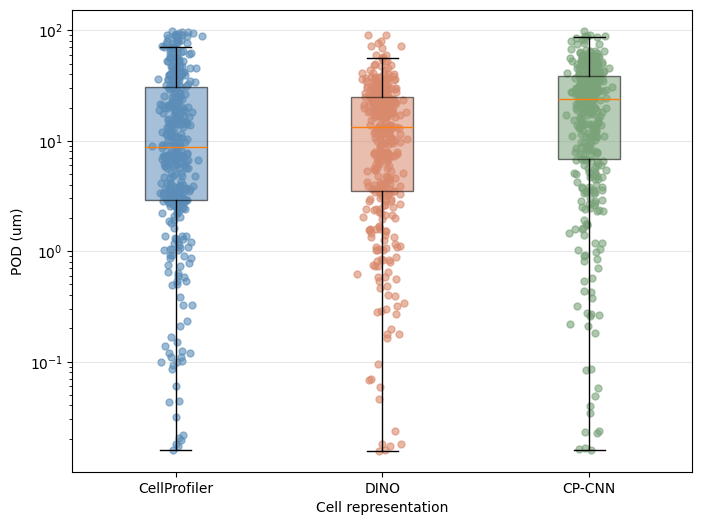

In [ ]:
import matplotlib.pyplot as plt

cols = [
    "POD_CellProfiler (um)",
    "POD_DINO (um)",
    "POD_CP-CNN (um)"
]

df_plot = df_all[cols].dropna()
df_plot = df_plot[(df_plot[cols] > 0).all(axis=1)]

data = [df_plot[col] for col in cols]

plt.figure(figsize=(8, 6))

colors = ["#5B8DB8", "#D9896C", "#7AA37A"]

bp = plt.boxplot(
    data,
    positions=[1, 2, 3],
    showfliers=False,
    patch_artist=True
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

for i, (values, color) in enumerate(zip(data, colors), start=1):
    jitter = np.random.normal(i, 0.04, size=len(values))

    plt.scatter(
        jitter,
        values,
        color=color,
        alpha=0.6,
        s=25
    )

plt.xticks(
    [1, 2, 3],
    ["CellProfiler", "DINO", "CP-CNN"]
)

plt.yscale("log")
plt.ylabel("POD (um)")
plt.xlabel("Cell representation")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
df_plot.count()

,0
POD_CellProfiler (um),386
POD_DINO (um),386
POD_CP-CNN (um),386


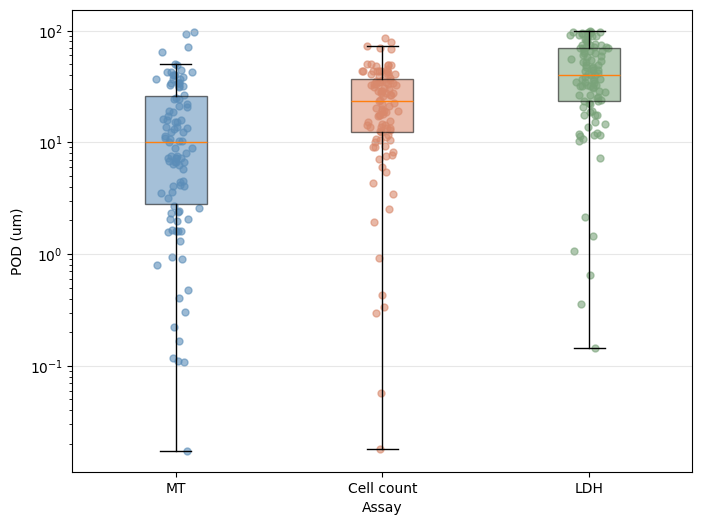

In [ ]:
cols = ["POD_MT (um)",
    "POD_Cell count (um)",
    "POD_LDH (um)"
]

# 세 값이 모두 있는 row만 선택
df_plot = df_all[cols].dropna()

# log scale에서는 0 이하 값 사용 불가
df_plot = df_plot[(df_plot[cols] > 0).all(axis=1)]

data = [df_plot[col] for col in cols]

plt.figure(figsize=(8, 6))

# Boxplot
colors = ["#5B8DB8", "#D9896C", "#7AA37A"]

bp = plt.boxplot(
    data,
    positions=[1, 2, 3],
    showfliers=False,
    patch_artist=True
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

# 실제 데이터 점
for i, (values, color) in enumerate(zip(data, colors), start=1):
    jitter = np.random.normal(i, 0.04, size=len(values))

    plt.scatter(
        jitter,
        values,
        color=color,
        alpha=0.6,
        s=25
    )
plt.xticks(
    [1, 2, 3],
    ["MT", "Cell count", "LDH"]
)

plt.yscale("log")

plt.xlabel("Assay")
plt.ylabel("POD (um)")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
print("n =", len(df_plot))

n = 102


# Plot PODs with baseline QSAR

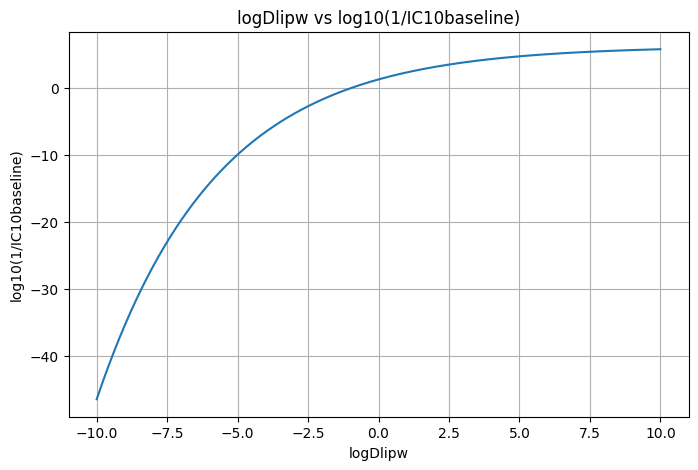

In [ ]:
# X range
X = np.linspace(-10, 10, 500)

# Y calculation
Y = 1.23 + 4.97 * (1 - np.exp(-0.236 * X))

# Graph
plt.figure(figsize=(8, 5))
plt.plot(X, Y)

plt.xlabel("logDlipw")
plt.ylabel("log10(1/IC10baseline)")
plt.title("logDlipw vs log10(1/IC10baseline)")

plt.grid(True)
plt.show()

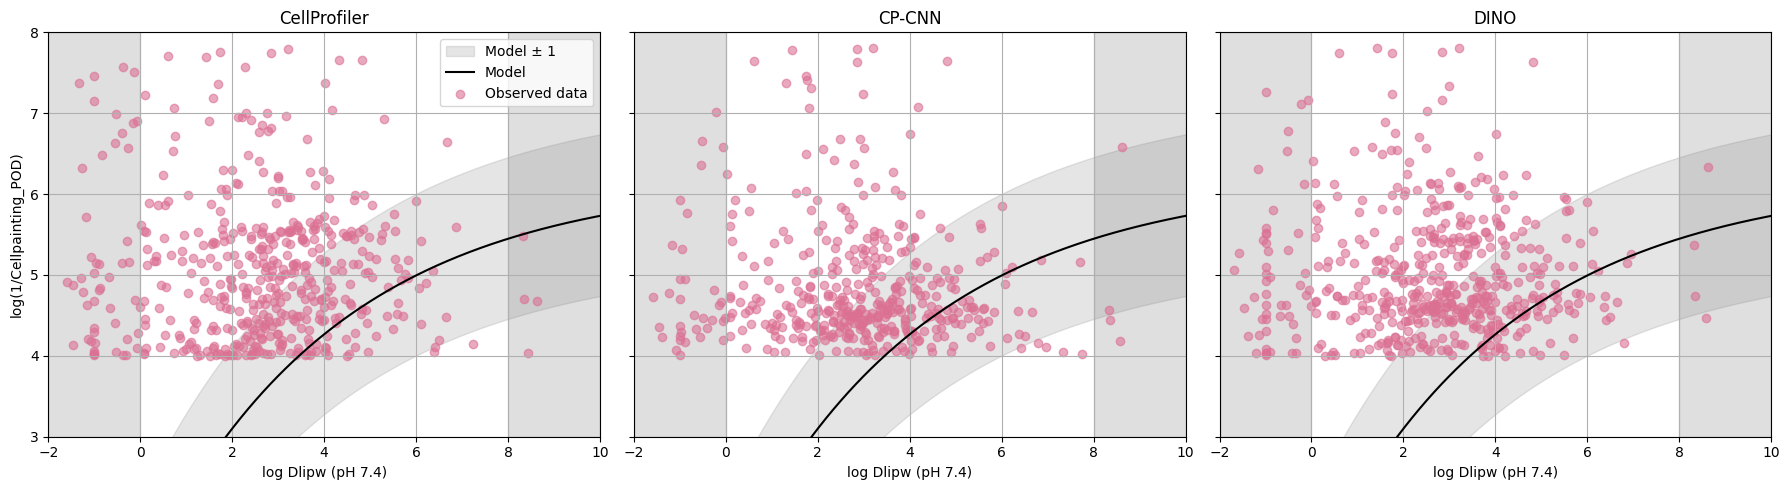

In [ ]:
# Generic cell/medium baseline QSAR + CP PoD comparison

# X data
x_data = df_all["log Dlipw (pH 7.4)"]

# 비교할 y 컬럼
pod_cols = [
    "POD_CellProfiler (um)",
    "POD_CP-CNN (um)",
    "POD_DINO (um)"
]

titles = [
    "CellProfiler",
    "CP-CNN",
    "DINO"
]

# 이론 곡선의 X 범위
X = np.linspace(x_data.min(), x_data.max(), 500)

# 이론식
Y = 1.23 + 4.97 * (1 - np.exp(-0.236 * X))

# 가로 3개 subplot
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)

for ax, pod_col, title in zip(axes, pod_cols, titles):

    # 각 POD 컬럼별 y 값
    y_data = -np.log10(df_all[pod_col] / (10**6))

    # 0보다 작은 구간 / 8보다 큰 구간 회색 처리
    ax.axvspan(-2, 0, color="gray", alpha=0.25)
    ax.axvspan(8, 10, color="gray", alpha=0.25)

    # 모델 Y ± 1
    ax.fill_between(
        X,
        Y - 1,
        Y + 1,
        color="gray",
        alpha=0.2,
        label="Model ± 1"
    )

    # 이론 곡선 - 검정색
    ax.plot(
        X,
        Y,
        color="black",
        label="Model"
    )

    # 실제 데이터
    ax.scatter(
        x_data,
        y_data,
        label="Observed data",
        color="palevioletred",
        alpha=0.6
    )

    ax.set_xlim(-2, 10)
    ax.set_ylim(3, 8)

    ax.set_xlabel("log Dlipw (pH 7.4)")
    ax.set_title(title)
    ax.grid(True)

# y축 label은 왼쪽에만
axes[0].set_ylabel("log(1/Cellpainting_POD)")

# legend는 한 번만
axes[0].legend()

plt.tight_layout()
plt.show()

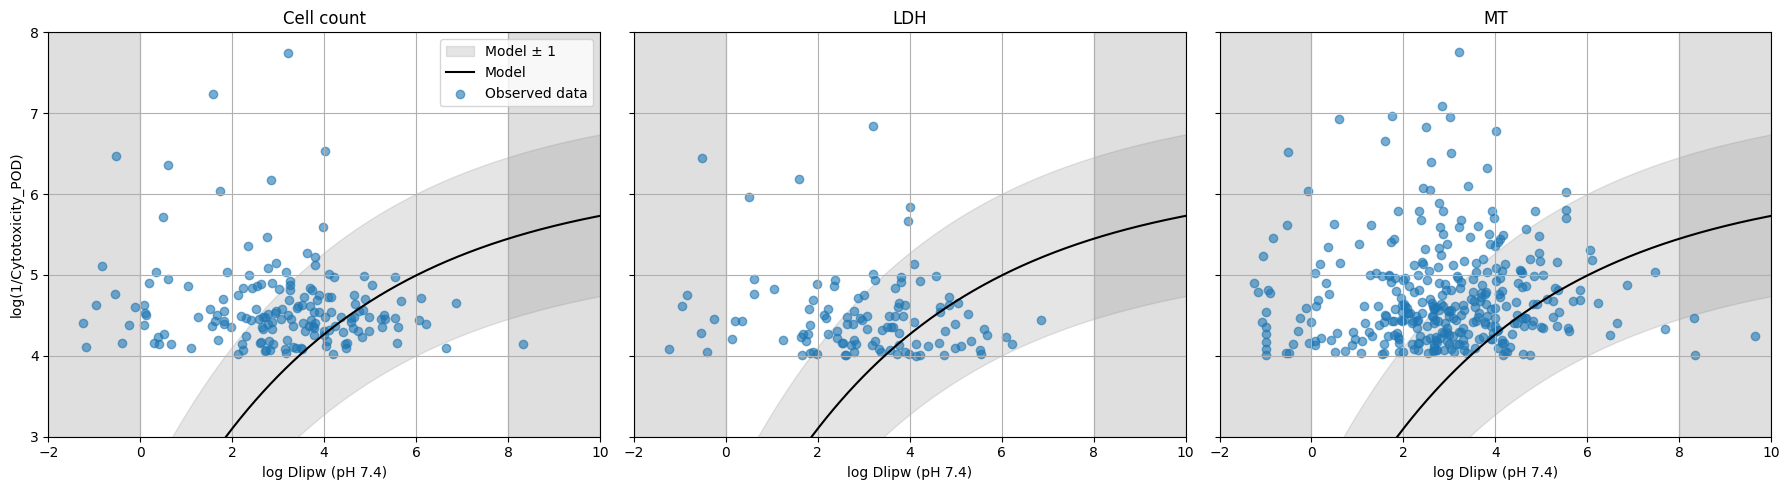

In [ ]:
# Generic cell/medium baseline QSAR + Cytotoxicity PoD comparison
import numpy as np
import matplotlib.pyplot as plt

# X data
x_data = df_all["log Dlipw (pH 7.4)"]

# 비교할 POD 컬럼
pod_cols = [
    "POD_Cell count (um)",
    "POD_LDH (um)",
    "POD_MT (um)"
]

titles = [
    "Cell count",
    "LDH",
    "MT"
]

# 이론 곡선의 X 범위
X = np.linspace(x_data.min(), x_data.max(), 500)

# 이론식
Y = 1.23 + 4.97 * (1 - np.exp(-0.236 * X))

# 가로 3개 subplot
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)

for ax, pod_col, title in zip(axes, pod_cols, titles):

    # 각 POD별 y 값
    y_data = -np.log10(df_all[pod_col] / (10**6))

    # 0보다 작은 구간 / 8보다 큰 구간 회색 처리
    ax.axvspan(-2, 0, color="gray", alpha=0.25)
    ax.axvspan(8, 10, color="gray", alpha=0.25)

    # 모델 Y ± 1
    ax.fill_between(
        X,
        Y - 1,
        Y + 1,
        color="gray",
        alpha=0.2,
        label="Model ± 1"
    )

    # 이론 곡선 - 검정색
    ax.plot(
        X,
        Y,
        color="black",
        label="Model"
    )

    # 실제 데이터
    ax.scatter(
        x_data,
        y_data,
        alpha=0.6,
        label="Observed data"
    )

    ax.set_xlim(-2, 10)
    ax.set_ylim(3, 8)

    ax.set_xlabel("log Dlipw (pH 7.4)")
    ax.set_title(title)
    ax.grid(True)

# y축 label은 왼쪽에만
axes[0].set_ylabel("log(1/Cytotoxicity_POD)")

# legend는 한 번만
axes[0].legend()

plt.tight_layout()
plt.show()

In [ ]:
# MT 값이 많다는 건, 장점이자 단점. false positive가 많으므로, 진짜 baseline toxicity인지 알수 없음 (너무 sensitive)

In [ ]:
# | log10(1/POD) | POD (M) | POD (µM) |
# | -----------: | ------: | -------: |
# |            8 |  `1e-8` |   `0.01` |
# |            9 |  `1e-9` |  `0.001` |

# tested at 8 concentrations on a semi-log scale (X 3.16)

In [ ]:
# # High protein/lipid content medium (AREC32 medium: DMEM glutamax + 10% FBS)
# import numpy as np
# import matplotlib.pyplot as plt

# # 실제 데이터
# x_data = df_dino_merged["log Dlipw (pH 7.4)"]
# y_data = -np.log10(df_dino_merged["POD_um"]/(10**6))

# # 이론 곡선의 X 범위
# X = np.linspace(x_data.min(), x_data.max(), 500)

# # 이론식
# Y = 1.25 + 4.01 * (1 - np.exp(-0.281 * X))

# # 그래프
# plt.figure(figsize=(8, 5))

# # 0보다 작은 구간 / 8보다 큰 구간 회색 처리
# plt.axvspan(x_data.min()-1, 0, color="gray", alpha=0.25)
# plt.axvspan(8, x_data.max(), color="gray", alpha=0.25)

# # 모델 Y ± 1 구간 회색 처리
# plt.fill_between(
#     X,
#     Y - 1,
#     Y + 1,
#     color="gray",
#     alpha=0.2,
#     label="Model ± 1"
# )
# # 이론 곡선
# plt.plot(
#     X,
#     Y,
#     label="Model"
# )

# # 실제 데이터
# plt.scatter(
#     x_data,
#     y_data,
#     label="Observed data",
#     color="palevioletred",
#     alpha=0.6
# )

# plt.xlim(-2, 10)
# plt.ylim(1, 8)

# plt.xlabel("log Dlipw (pH 7.4)")
# plt.ylabel("log(1/Bioactivity_POD)")
# plt.legend()
# plt.grid(True)
# plt.show()

# Additional analysis

In [ ]:
# Q1.
# CP랑 DINO에서 global비율 찾아보기 - 지금 CP랑 DINO는 global이랑 category 섞여잇음 - 분리할지 고민하기

In [ ]:
pd.set_option('display.max_columns', None)
df_all.head(5)

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow,log Dlipw (pH 7.4),Source,"log(1/IC10,baseline)",Assay_Endpoint_CellProfiler,POD_CellProfiler (um),Assay_Endpoint_CP-CNN,POD_CP-CNN (um),Assay_Endpoint_DINO,POD_DINO (um),POD_Cell count (um),POD_LDH (um),POD_MT (um),SRbaseline_CellProfiler,SRbaseline_CP-CNN,SRbaseline_DINO,TR_Cell count,TR_LDH,TR_MT
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000,PlayMolecule AcepKa,0.46,PhysPropNCCT,0.580587,Kow QSAR (∆mw = 1),1.866388,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000,PlayMolecule AcepKa,-0.02,PhysPropNCCT,0.081046,Kow QSAR (∆mw = 1),1.324157,Nuclei_AGP,95.911135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,494.281238,NaN,NaN,NaN,NaN,NaN
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000,PlayMolecule AcepKa,4.35,PhysPropNCCT,4.492217,Kow QSAR (∆mw = 1),4.478396,Cytoplasm_RNA,3.282117,gmd,13.245321,Mito,12.282116,69.877312,NaN,12.603203,10.126285,2.509237,2.706020,0.475629,NaN,2.63708
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,0.420755,PlayMolecule AcepKa,-1.30,PhysPropNCCT,-1.000000,fixed @ -1 at logKow < -1 (Gobas 1988),-0.092886,NaN,NaN,gmd,98.768244,Brightfield,30.293853,NaN,NaN,NaN,NaN,12539.175699,40881.969692,NaN,NaN,NaN
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000,PlayMolecule AcepKa,1.39,PhysPropNCCT,1.523900,Kow QSAR,2.731302,Nuclei_ER,99.289088,gmd,41.276806,gmd,21.425531,NaN,NaN,NaN,18.698077,44.977196,86.649660,NaN,NaN,NaN


In [ ]:
pd.reset_option('display.max_columns')

In [ ]:
df_all['Assay_Endpoint_CellProfiler'].value_counts()

,count
Assay_Endpoint_CellProfiler,
Nuclei_DNA,70
Nuclei_AreaShape,43
Cytoplasm_RNA,41
Cytoplasm_DNA,31
Cells_RNA,30
Cells_AGP,29
Cytoplasm_AGP,27
Nuclei_RNA,26
Nuclei_AGP,22


In [ ]:
df_all['Assay_Endpoint_CP-CNN'].value_counts()

,count
Assay_Endpoint_CP-CNN,
gmd,432


In [ ]:
df_all['Assay_Endpoint_DINO'].value_counts()

,count
Assay_Endpoint_DINO,
gmd,242
RNA,77
ER,49
Brightfield,47
Mito,44
AGP,35
DNA,25


In [ ]:
df_cp_pod

,OASIS_ID,Cell_representation,Compound_name,Assay_Endpoint,POD_um,POD_um_l,POD_um_u,Bioactivity_POD,Min,Min_Bioactivity_match
0,OASIS1758,CellProfiler,Omadacycline,Cytoplasm_AreaShape,64.795643,62.932566,66.604753,False,False,True
1,OASIS1758,CellProfiler,Omadacycline,Cytoplasm_Mito,51.118303,47.333805,54.894826,True,True,True
2,OASIS557,CellProfiler,Fluazinam,Cells_AGP,4.660165,4.187263,5.104732,False,False,True
3,OASIS557,CellProfiler,Fluazinam,Cells_AreaShape,15.771461,15.573828,15.959585,False,False,True
4,OASIS557,CellProfiler,Fluazinam,Cells_DNA,0.148563,0.135881,0.163199,False,False,True
...,...,...,...,...,...,...,...,...,...,...
10929,OASIS1793,CP-CNN,Bedaquiline (fumarate),gmd,34.413043,33.532602,35.301422,True,True,True
10930,OASIS1728,CP-CNN,Diroximel fumarate,gmd,27.428922,26.894938,27.963753,True,True,True
10931,OASIS666,CP-CNN,Ibufenac,gmd,30.209281,29.646079,30.771133,True,True,True
10932,OASIS1112,CP-CNN,Nimodipine,gmd,84.016533,81.879052,86.125939,True,True,True


In [ ]:
# 조건에 맞는 OASIS_ID 추출
target_ids = df_cp_pod.loc[
    (df_cp_pod['Cell_representation'] == 'DINO') &
    (df_cp_pod['Assay_Endpoint'] == 'gmd') &
    (df_cp_pod['Bioactivity_POD'] == True),
    'OASIS_ID'
].unique()

# 해당 OASIS_ID를 가진 모든 row 출력
result = df_cp_pod[(df_cp_pod['OASIS_ID'].isin(target_ids)) &
                    (df_cp_pod['Cell_representation'] == 'DINO')]

pd.set_option('display.max_rows', None)
result

,OASIS_ID,Cell_representation,Compound_name,Assay_Endpoint,POD_um,POD_um_l,POD_um_u,Bioactivity_POD,Min,Min_Bioactivity_match
6968,OASIS1553,DINO,Quetiapine,AGP,27.793875,26.563562,29.040689,False,False,True
6969,OASIS1553,DINO,Quetiapine,Brightfield,44.789606,43.763768,45.817159,False,False,True
6970,OASIS1553,DINO,Quetiapine,DNA,55.543984,53.577893,57.493623,False,False,True
6971,OASIS1553,DINO,Quetiapine,ER,22.666435,21.269105,24.089854,False,False,True
6972,OASIS1553,DINO,Quetiapine,gmd,20.864610,19.748219,22.001575,True,True,True
6973,OASIS1553,DINO,Quetiapine,Mito,31.716071,30.489044,32.957621,False,False,True
6974,OASIS1553,DINO,Quetiapine,RNA,25.272407,23.882060,26.682815,False,False,True
6975,OASIS305,DINO,Bezafibrate,AGP,28.251135,24.095145,33.032206,False,False,True
6976,OASIS305,DINO,Bezafibrate,ER,73.521237,70.490637,76.527645,False,False,True
6977,OASIS305,DINO,Bezafibrate,gmd,15.596654,11.100629,21.966039,True,True,True


In [ ]:
pd.reset_option('display.max_rows', None)

In [ ]:
len(target_ids)

262

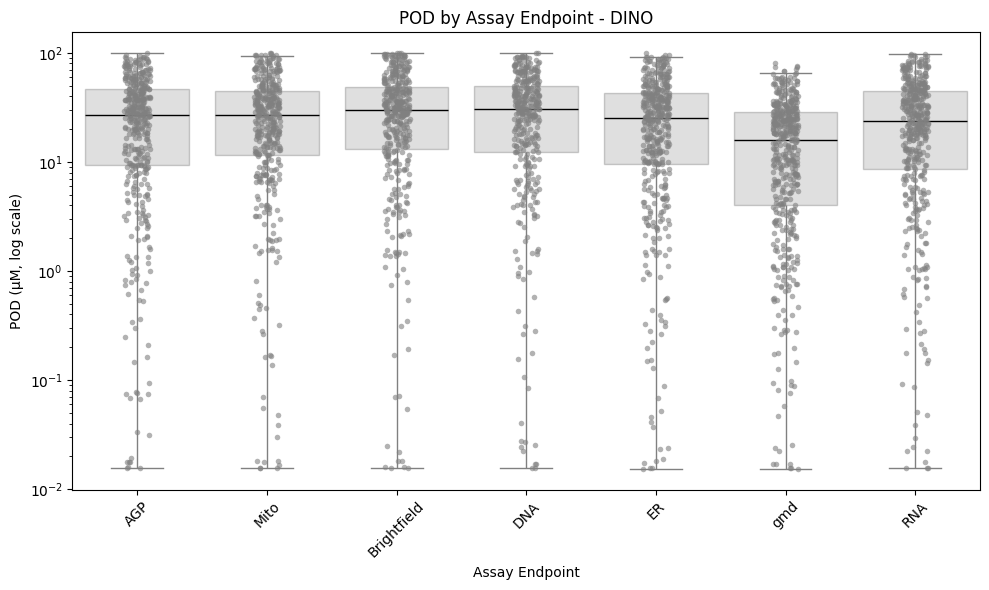

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# DINO만 필터링
df_dino = df_cp_pod[
    df_cp_pod['Cell_representation'] == 'DINO'
].copy()

# Assay_Endpoint 순서 확인
endpoint_order = df_dino['Assay_Endpoint'].dropna().unique()

# 1. 점 플롯
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_dino,
    x='Assay_Endpoint',
    y='POD_um',
    order=endpoint_order,
    showfliers=False,
    boxprops=dict(
        facecolor='gray',
        alpha=0.25
    ),
    medianprops=dict(
        color='black'
    ),
    whiskerprops=dict(
        color='gray'
    ),
    capprops=dict(
        color='gray'
    )
)

sns.stripplot(
    data=df_dino,
    x='Assay_Endpoint',
    y='POD_um',
    order=endpoint_order,
    jitter=True,
    color='gray',
    alpha=0.6,
    size=4
)

plt.yscale('log')

plt.xlabel('Assay Endpoint')
plt.ylabel('POD (µM, log scale)')
plt.title('POD by Assay Endpoint - DINO')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 오히려 아예 cytotoxic한 애라서? 세부 구조에서는 잡히지 않고 전체에서 잡히나?...

In [ ]:
# Q2.
# LDH 만으로 strict하게 CP category 별로 어떤 변화가 있는지 알아보는 방향으로?
# LDH positive는 cell count랑 MT positive랑도 많이 겹치는지 찾이보기 (정당성 부여)

In [ ]:
df_cytotox_pod

,OASIS_ID,Assay,Compound_name,POD_um,POD_um_l,POD_um_u
0,OASIS007,MT,Nitrofurazone,4.544274,4.344033,4.747511
1,OASIS188,MT,Maropitant,21.179257,20.836759,21.514168
2,OASIS1788,MT,Nifurtimox,24.506731,23.605215,25.434312
4,OASIS1455,MT,Gefitinib,12.471706,12.221362,12.717598
5,OASIS1015,MT,Lansoprazole,24.470523,23.840475,25.093253
...,...,...,...,...,...,...
790,OASIS1772,LDH,Afatinib,19.180914,18.361229,20.020715
791,OASIS1823,LDH,Palbociclib,54.241545,49.456238,59.416972
792,OASIS1304,LDH,Fluoxetine,65.154027,63.719538,66.587828
793,OASIS093,LDH,Clomipramine,75.287280,73.105596,77.474702


In [ ]:
presence = (
    df_cytotox_pod
    .assign(present=1)
    .pivot_table(
        index='OASIS_ID',
        columns='Assay',
        values='present',
        aggfunc='max',
        fill_value=0
    )
)

presence.head()

Assay,Cell count,LDH,MT
OASIS_ID,,,
OASIS004,1,0,1
OASIS007,1,1,1
OASIS011,1,1,1
OASIS014,0,0,1
OASIS018,0,0,1


In [ ]:
ldh = presence[presence['LDH'] == 1]

In [ ]:
n_ldh = len(ldh)
ldh_overlap = pd.Series({
    'LDH only': ((ldh['MT'] == 0) & (ldh['Cell count'] == 0)).sum(),
    'LDH + MT only': ((ldh['MT'] == 1) & (ldh['Cell count'] == 0)).sum(),
    'LDH + Cell count only': ((ldh['MT'] == 0) & (ldh['Cell count'] == 1)).sum(),
    'LDH + MT + Cell count': ((ldh['MT'] == 1) & (ldh['Cell count'] == 1)).sum(),
    'Total': n_ldh
})

result = pd.DataFrame({
    'count': ldh_overlap,
    'percent': ldh_overlap / n_ldh * 100
})

result

,count,percent
LDH only,3,2.307692
LDH + MT only,6,4.615385
LDH + Cell count only,0,0.000000
LDH + MT + Cell count,121,93.076923
Total,130,100.000000


In [ ]:
# LDH만 positive인건 3개뿐, 나머지 127개는 무조건 MT랑 같이 positive. 전체 중 121개는 세가지 cytotox 모두 다같이 positive
# LDH가 positive면 다른 두개는 모두 positive일 확률이 높으므로 false positive 확률이 매우 낮음. 가장 strict한 cytotoxicity endpoint임

# LDH 기준 baseline toxicity 먼저 분석해보기 (conservative baseline toxicants)

In [ ]:
# - 어떤 category가 주로 CP에 잡혔는지

In [ ]:
df_all.head()

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),...,POD_DINO (um),POD_Cell count (um),POD_LDH (um),POD_MT (um),SRbaseline_CellProfiler,SRbaseline_CP-CNN,SRbaseline_DINO,TR_Cell count,TR_LDH,TR_MT
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000,...,NaN,NaN,NaN,NaN,494.281238,NaN,NaN,NaN,NaN,NaN
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000,...,12.282116,69.877312,NaN,12.603203,10.126285,2.509237,2.706020,0.475629,NaN,2.63708
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,0.420755,...,30.293853,NaN,NaN,NaN,NaN,12539.175699,40881.969692,NaN,NaN,NaN
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000,...,21.425531,NaN,NaN,NaN,18.698077,44.977196,86.649660,NaN,NaN,NaN


In [ ]:
df_all["SRcytotox(LDH)_CellProfiler"] = (df_all['POD_LDH (um)']) / (df_all['POD_CellProfiler (um)'])
df_all["SRcytotox(LDH)_CP-CNN"] = (df_all['POD_LDH (um)']) / (df_all['POD_CP-CNN (um)'])
df_all["SRcytotox(LDH)_DINO"] = (df_all['POD_LDH (um)']) / (df_all['POD_DINO (um)'])

In [ ]:
df_all.head()

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),...,POD_MT (um),SRbaseline_CellProfiler,SRbaseline_CP-CNN,SRbaseline_DINO,TR_Cell count,TR_LDH,TR_MT,SRcytotox(LDH)_CellProfiler,SRcytotox(LDH)_CP-CNN,SRcytotox(LDH)_DINO
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000,...,NaN,494.281238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000,...,12.603203,10.126285,2.509237,2.706020,0.475629,NaN,2.63708,NaN,NaN,NaN
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,0.420755,...,NaN,NaN,12539.175699,40881.969692,NaN,NaN,NaN,NaN,NaN,NaN
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000,...,NaN,18.698077,44.977196,86.649660,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cols = [
    'SRcytotox(LDH)_CellProfiler',
    'SRcytotox(LDH)_CP-CNN',
    'SRcytotox(LDH)_DINO'
]

summary = df_all[cols].agg([
    'mean',
    'median',
    'std',
    'min',
    'max'
]).T

summary['n'] = df_all[cols].count()
summary['n_nan'] = df_all[cols].isna().sum()

summary

,mean,median,std,min,max,n,n_nan
SRcytotox(LDH)_CellProfiler,77.517197,13.497773,373.804670,1.064923,3793.541402,110,782
SRcytotox(LDH)_CP-CNN,32.429299,4.639449,190.378082,0.574960,1914.150786,107,785
SRcytotox(LDH)_DINO,53.502258,5.375882,353.978814,0.783648,3671.254131,110,782


In [ ]:
# 일단 CellProfiler랑 DINO는 같은 개수의 LDH positive를 잡아낸데 비해, CP-CNN은 3개 덜 잡아냄.
# 누구인지 중요하려나? 혹시 위에서 LDH만 positive였던 그 3개는 아니려나?
# 110개가 모두 중복이려나? 아니면 세부적으로는 다르려나?

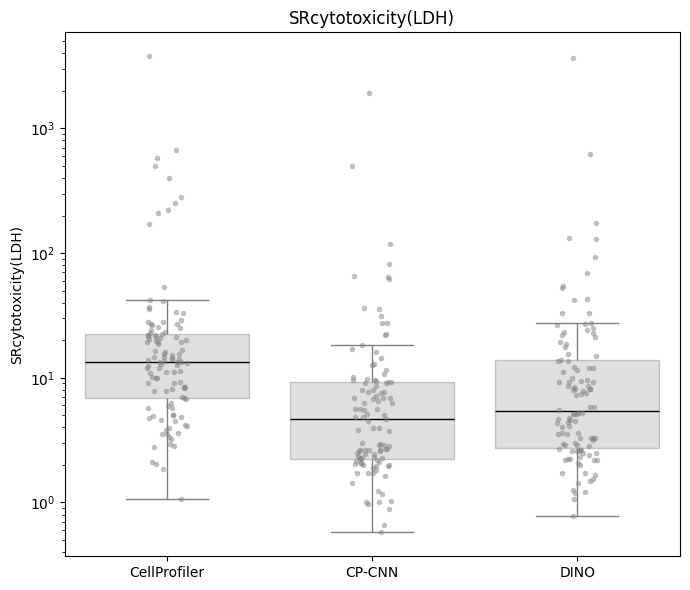

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'SRcytotox(LDH)_CellProfiler',
    'SRcytotox(LDH)_CP-CNN',
    'SRcytotox(LDH)_DINO'
]

# long format으로 변환
plot_df = df_all[cols].melt(
    var_name='Method',
    value_name='SRcytotoxicity(LDH)'
)

# x축 이름 간단하게 변경
plot_df['Method'] = plot_df['Method'].replace({
    'SRcytotox(LDH)_CellProfiler': 'CellProfiler',
    'SRcytotox(LDH)_CP-CNN': 'CP-CNN',
    'SRcytotox(LDH)_DINO': 'DINO'
})

plt.figure(figsize=(7, 6))

# Box plot
sns.boxplot(
    data=plot_df,
    x='Method',
    y='SRcytotoxicity(LDH)',
    showfliers=False,
    boxprops=dict(
        facecolor='gray',
        alpha=0.25
    ),
    medianprops=dict(color='black'),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 실제 데이터 점
sns.stripplot(
    data=plot_df,
    x='Method',
    y='SRcytotoxicity(LDH)',
    color='gray',
    alpha=0.5,
    jitter=True,
    size=4
)

plt.xlabel('')
plt.ylabel('SRcytotoxicity(LDH)')
plt.title('SRcytotoxicity(LDH)')
plt.yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
# Grouping
baseline_LDH_CellProfiler = df_all[(df_all['TR_LDH'] <= 10) &
                                    (df_all['SRcytotox(LDH)_CellProfiler'] <= 10)].copy()
baseline_LDH_CPCNN = df_all[(df_all['TR_LDH'] <= 10) &
                                    (df_all['SRcytotox(LDH)_CP-CNN'] <= 10)].copy()
baseline_LDH_DINO = df_all[(df_all['TR_LDH'] <= 10) &
                                    (df_all['SRcytotox(LDH)_DINO'] <= 10)].copy()



In [ ]:
baseline_LDH_CellProfiler["Assay_Endpoint_CellProfiler"].value_counts()

,count
Assay_Endpoint_CellProfiler,
Nuclei_DNA,4
Nuclei_Mito,3
Nuclei_AreaShape,3
Cells_RNA,3
Nuclei_RNA,2
gmd,2
Cytoplasm_Mito,2
Cells_Mito,1
Cytoplasm_RNA,1


In [ ]:
baseline_LDH_DINO["Assay_Endpoint_DINO"].value_counts()

,count
Assay_Endpoint_DINO,
gmd,18
RNA,10
ER,6
AGP,4
Mito,3
Brightfield,2
DNA,2


In [ ]:
import pandas as pd

tr = df_all['TR_LDH']

sr_cols = {
    'CellProfiler': 'SRcytotox(LDH)_CellProfiler',
    'CP-CNN': 'SRcytotox(LDH)_CP-CNN',
    'DINO': 'SRcytotox(LDH)_DINO'
}

results = {}

for name, col in sr_cols.items():
    sr = df_all[col]

    both_determined = tr.notna() & sr.notna()

    # 1) 0.1 <= TR <= 10 & 0.1 <= SR <= 10
    cond_1 = (
        both_determined &
        tr.between(0.1, 10, inclusive='both') &
        sr.between(0.1, 10, inclusive='both')
    )

    # 2) TR > 10 & 0.1 <= SR <= 10
    cond_2 = (
        both_determined &
        (tr > 10) &
        sr.between(0.1, 10, inclusive='both')
    )

    # 3) 0.1 <= TR <= 10 & SR > 10
    cond_3 = (
        both_determined &
        tr.between(0.1, 10, inclusive='both') &
        (sr > 10)
    )

    # 4) TR > 10 & SR > 10
    cond_4 = (
        both_determined &
        (tr > 10) &
        (sr > 10)
    )

    others = both_determined & ~(cond_1 | cond_2 | cond_3 | cond_4)

    results[name] = [
        both_determined.sum(),
        cond_1.sum(),
        cond_2.sum(),
        cond_3.sum(),
        cond_4.sum(),
        others.sum()
    ]

summary_table = pd.DataFrame(
    results,
    index=[
        'TR & SR both determined',
        '0.1 <= TR <=10 & 0.1 <= SR <=10',
        '10 < TR & 0.1 <= SR <=10',
        '0.1 <= TR <=10 & 10 < SR',
        '10 < TR & 10 < SR',
        'others'
    ]
)

summary_table

,CellProfiler,CP-CNN,DINO
TR & SR both determined,110,107,110
0.1 <= TR <=10 & 0.1 <= SR <=10,24,57,45
10 < TR & 0.1 <= SR <=10,17,27,30
0.1 <= TR <=10 & 10 < SR,47,14,26
10 < TR & 10 < SR,22,9,9
others,0,0,0


In [ ]:
import pandas as pd

contingency_tables = {}

# CellProfiler
contingency_tables['CellProfiler'] = pd.DataFrame(
    [
        [24, 47],
        [17, 22]
    ],
    index=['TR <= 10', '10 < TR'],
    columns=['SR <= 10', '10 < SR']
)

# CP-CNN
contingency_tables['CP-CNN'] = pd.DataFrame(
    [
        [57, 14],
        [27, 9]
    ],
    index=['TR <= 10', '10 < TR'],
    columns=['SR <= 10', '10 < SR']
)

# DINO
contingency_tables['DINO'] = pd.DataFrame(
    [
        [45, 26],
        [30, 9]
    ],
    index=['TR <= 10', '10 < TR'],
    columns=['SR <= 10', '10 < SR']
)

for name, table in contingency_tables.items():
    print(f'\n{name}')
    display(table)


CellProfiler


,SR <= 10,10 < SR
TR <= 10,24,47
10 < TR,17,22



CP-CNN


,SR <= 10,10 < SR
TR <= 10,57,14
10 < TR,27,9



DINO


,SR <= 10,10 < SR
TR <= 10,45,26
10 < TR,30,9


In [ ]:
# 부족하다면, cytotoxicity pod가 결정되지 않은 애들에 대해서 최고 농도 기준으로 TR 과 SR을 산정할수 잇음

In [ ]:
result = df_cp_pod[
    (df_cp_pod['Cell_representation'] == 'DINO') &
    (df_cp_pod['OASIS_ID'].isin(baseline_LDH_DINO['OASIS_ID']))
]

result

,OASIS_ID,Cell_representation,Compound_name,Assay_Endpoint,POD_um,POD_um_l,POD_um_u,Bioactivity_POD,Min,Min_Bioactivity_match
6993,OASIS1345,DINO,Fluspirilene,AGP,26.853184,26.226790,27.473269,False,False,True
6994,OASIS1345,DINO,Fluspirilene,Brightfield,36.629951,36.174067,37.080824,False,False,True
6995,OASIS1345,DINO,Fluspirilene,DNA,44.681108,43.791362,45.548570,False,False,True
6996,OASIS1345,DINO,Fluspirilene,ER,20.005439,19.502294,20.491813,True,True,True
6997,OASIS1345,DINO,Fluspirilene,gmd,28.309849,27.671320,28.936551,False,False,True
...,...,...,...,...,...,...,...,...,...,...
10388,OASIS1320,DINO,Piperacetazine,DNA,4.783688,4.630586,4.937972,False,False,True
10389,OASIS1320,DINO,Piperacetazine,ER,6.624732,6.437850,6.809464,False,False,True
10390,OASIS1320,DINO,Piperacetazine,gmd,4.539846,4.413892,4.665198,True,True,True
10391,OASIS1320,DINO,Piperacetazine,Mito,10.417690,10.244429,10.589474,False,False,True


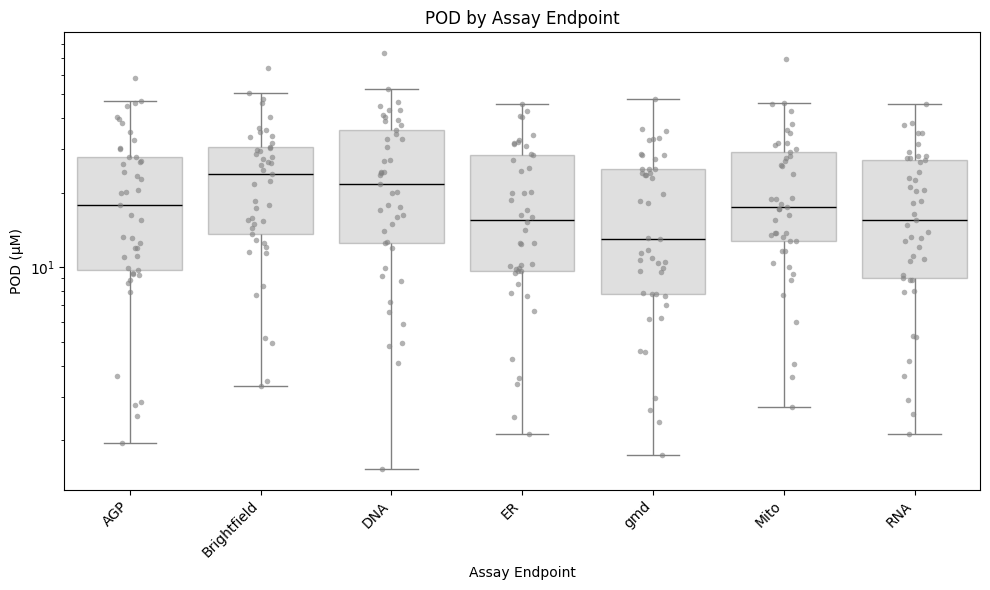

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# POD_um이 양수인 값만 사용 (log scale 때문)
plot_df = result[
    result['POD_um'].notna() &
    (result['POD_um'] > 0)
].copy()

plt.figure(figsize=(10, 6))

# Box plot
sns.boxplot(
    data=plot_df,
    x='Assay_Endpoint',
    y='POD_um',
    showfliers=False,
    boxprops=dict(
        facecolor='gray',
        alpha=0.25
    ),
    medianprops=dict(color='black'),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 개별 데이터 점
sns.stripplot(
    data=plot_df,
    x='Assay_Endpoint',
    y='POD_um',
    color='gray',
    alpha=0.6,
    jitter=True,
    size=4
)

# log scale
plt.yscale('log')

plt.xlabel('Assay Endpoint')
plt.ylabel('POD (µM)')
plt.title('POD by Assay Endpoint')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# 특정 category가 baseline toxicity랑 연관이 있을 수 있다고 생각했는데 그렇지 않은듯. DINO는 gmd에서 많이 나오긴 했지만 압도적인 숫자는 아님.
# 어쨌든 중요한 건 전반적인 패턴이 비슷하게 분류되는지이니까, umap을 baseline 그룹별로 해보기
# 이번에는 (1) cytotox있는 애들도 포함한거랑, 없는거랑, (2) active한 부분만 포함한거랑 포함안한거랑 다 비교해보기.

In [ ]:
# Save df_all into parquet
df_all.to_parquet("data_combined.parquet", index=False)
# https://drive.google.com/file/d/1BVsOWXWRC96aRAlIpY04vXQiR4AjRDno/view?usp=sharing

# Saving point: 여기서부터 시작해도 됨 - df_all import

In [ ]:
import gdown
import numpy as np
import pandas as pd

file_id = "1BVsOWXWRC96aRAlIpY04vXQiR4AjRDno"
output = "df_all.parquet"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    output,
    quiet=False
)

df_all = pd.read_parquet(output)

df_all.head()

Downloading...
From: https://drive.google.com/uc?id=1BVsOWXWRC96aRAlIpY04vXQiR4AjRDno
To: /content/df_all.parquet
100%|██████████| 170k/170k [00:00<00:00, 20.7MB/s]


,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),...,POD_MT (um),SRbaseline_CellProfiler,SRbaseline_CP-CNN,SRbaseline_DINO,TR_Cell count,TR_LDH,TR_MT,SRcytotox(LDH)_CellProfiler,SRcytotox(LDH)_CP-CNN,SRcytotox(LDH)_DINO
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000,...,NaN,494.281238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000,...,12.603203,10.126285,2.509237,2.706020,0.475629,NaN,2.63708,NaN,NaN,NaN
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,0.420755,...,NaN,NaN,12539.175699,40881.969692,NaN,NaN,NaN,NaN,NaN,NaN
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000,...,NaN,18.698077,44.977196,86.649660,NaN,NaN,NaN,NaN,NaN,NaN


# Group column based on TR and SR (LDH and DINO)

In [ ]:
# Add group column based on TR_LDH & SRcytotox(LDH)_DINO

tr = df_all["TR_LDH"]
sr = df_all["SRcytotox(LDH)_DINO"]

df_all["Group (LDH/DINO)"] = pd.Series(
    "others",
    index=df_all.index,
    dtype="object"
)

# group 1: TR, SR 모두 0.1 이상 10 이하
df_all.loc[
    tr.between(0.1, 10, inclusive="both") &
    sr.between(0.1, 10, inclusive="both"),
    "Group (LDH/DINO)"
] = "group 1"

# group 2: TR > 10, SR은 0.1 이상 10 이하
df_all.loc[
    (tr > 10) &
    sr.between(0.1, 10, inclusive="both"),
    "Group (LDH/DINO)"
] = "group 2"

# group 3: TR은 0.1 이상 10 이하, SR > 10
df_all.loc[
    tr.between(0.1, 10, inclusive="both") &
    (sr > 10),
    "Group (LDH/DINO)"
] = "group 3"

# group 4: TR, SR 모두 10 초과
df_all.loc[
    (tr > 10) &
    (sr > 10),
    "Group (LDH/DINO)"
] = "group 4"

# 둘 중 하나라도 결측값이면 NaN
df_all.loc[
    tr.isna() | sr.isna(),
    "Group (LDH/DINO)"
] = np.nan

In [ ]:
df_all["Group (LDH/DINO)"].value_counts()

,count
Group (LDH/DINO),
group 1,45
group 2,30
group 3,26
group 4,9


In [ ]:
# 나중에 NaN인 애들중에 최고 독성값으로 specific한지 여부는 판단할 수 잇음.

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

df_all.sort_values(by = "Group (LDH/DINO)").head(110)

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow,log Dlipw (pH 7.4),Source,"log(1/IC10,baseline)",Assay_Endpoint_CellProfiler,POD_CellProfiler (um),Assay_Endpoint_CP-CNN,POD_CP-CNN (um),Assay_Endpoint_DINO,POD_DINO (um),POD_Cell count (um),POD_LDH (um),POD_MT (um),SRbaseline_CellProfiler,SRbaseline_CP-CNN,SRbaseline_DINO,TR_Cell count,TR_LDH,TR_MT,SRcytotox(LDH)_CellProfiler,SRcytotox(LDH)_CP-CNN,SRcytotox(LDH)_DINO,Group (LDH/DINO)
274,Apomorphine,OASIS1396,s0617936,DTXSID8022614,58-00-4,CN1CCC2=CC=CC3=C2[C@H]1CC1=C3C(O)=C(O)C=C1,2.671712e-01,8.907734e-03,5.735436e-01,1.503775e-01,PlayMolecule AcepKa,2.30,PhysPropNCCT,1.975059,Kow QSAR (∆mw = 1),3.081644,Nuclei_Mito,11.163396,gmd,25.355923,RNA,20.582751,43.776645,94.236661,37.038337,7.422666e+01,3.267961e+01,4.025806e+01,18.928395,8.792986,22.371998,8.441577,3.716554,4.578429,group 1
263,Fesoterodine,OASIS1379,s0618030,DTXSID80182853,286930-02-7,CC(C)N(CC[C@H](C1=CC=CC=C1)C1=C(OC(=O)C(C)C)C=...,3.641684e-03,2.820000e-07,9.963580e-01,0.000000e+00,PlayMolecule AcepKa,4.91,OPERA2.8,4.093106,Kow QSAR (∆mw = 1),4.308355,Nuclei_Mito,2.881743,gmd,14.305001,ER,9.492590,18.864036,38.409860,18.676965,1.706042e+01,3.436823e+00,5.179173e+00,2.606216,1.279978,2.632321,13.328689,2.685065,4.046299,group 1
487,Baloxavir marboxil,OASIS1853,s0618273,DTXSID601027758,1985606-14-1,[H][C@@]12COCCN1C(=O)C1=C(OCOC(=O)OC)C(=O)C=CN...,9.999999e-01,0.000000e+00,1.210000e-07,0.000000e+00,PlayMolecule AcepKa,2.93,OPERA2.8,3.079300,Kow QSAR (∆mw = 1),3.797031,Nuclei_RNA,0.903866,gmd,12.232098,Brightfield,3.470445,26.582279,32.186495,7.546563,1.765490e+02,1.304572e+01,4.598158e+01,6.003117,4.957872,21.145588,35.609825,2.631314,9.274459,group 1
284,Mequitazine,OASIS1418,s0618590,DTXSID8023262,29216-28-2,C(C1CN2CCC1CC2)N1C2=CC=CC=C2SC2=C1C=CC=C2,1.482865e-02,0.000000e+00,9.851714e-01,0.000000e+00,PlayMolecule AcepKa,5.53,OPERA2.8,4.759705,Kow QSAR (∆mw = 1),4.583717,Cytoplasm_Mito,2.974634,gmd,8.686466,RNA,10.545311,27.676469,48.935042,6.351995,8.766978e+00,3.002205e+00,2.473000e+00,0.942264,0.532922,4.105569,16.450776,5.633481,4.640455,group 1
292,Primaquine,OASIS1434,s0618082,DTXSID8023509,90-34-6,COC1=CC(NC(C)CCCN)=C2N=CC=CC2=C1,1.336612e-03,0.000000e+00,9.986634e-01,0.000000e+00,PlayMolecule AcepKa,3.27,OPERA2.8,2.427893,Kow QSAR (∆mw = 1),3.397710,Cells_Mito,6.046904,gmd,8.717709,gmd,9.519520,14.557512,49.150142,7.278254,6.618464e+01,4.590796e+01,4.204121e+01,27.491798,8.142646,54.987387,8.128149,5.637966,5.163090,group 1
302,Gefitinib,OASIS1455,s0618654,DTXSID8041034,184475-35-2,COC1=C(OCCCN2CCOCC2)C=C2C(NC3=CC(Cl)=C(F)C=C3)...,5.405104e-01,3.600000e-07,4.594892e-01,0.000000e+00,PlayMolecule AcepKa,2.86,OPERA2.8,2.776838,Kow QSAR (∆mw = 1),3.619234,Nuclei_AreaShape,10.740771,gmd,6.643561,RNA,7.935931,30.574778,63.310099,12.471706,2.237330e+01,3.617134e+01,3.028082e+01,7.859633,3.795706,19.268136,5.894372,9.529543,7.977652,group 1
316,Cinacalcet,OASIS1479,s0618829,DTXSID8048286,226256-56-0,C[C@@H](NCCCC1=CC=CC(=C1)C(F)(F)F)C1=CC=CC2=CC...,9.504526e-03,0.000000e+00,9.904955e-01,0.000000e+00,PlayMolecule AcepKa,5.77,OPERA2.8,4.983346,Kow QSAR (∆mw = 1),4.666811,Nuclei_ER,3.397646,gmd,39.531294,AGP,24.310744,49.131412,79.509404,44.014556,6.338862e+00,5.448142e-01,8.859132e-01,0.438359,0.270876,0.489320,23.401321,2.011303,3.270546,group 1
622,Azoxystrobin,OASIS419,s0618479,DTXSID0032520,131860-33-8,CO\C=C(\C(=O)OC)C1=CC=CC=C1OC1=CC(OC2=CC=CC=C2...,9.999981e-01,0.000000e+00,1.950000e-06,0.000000e+00,PlayMolecule AcepKa,2.50,PhysPropNCCT,2.644999,Kow QSAR (∆mw = 1),3.537674,Nuclei_AreaShape,2.933037,gmd,15.550565,gmd,9.943789,43.751537,32.808097,24.372240,9.885713e+01,1.864573e+01,2.915907e+01,6.627233,8.837808,11.896799,11.185708,2.109769,3.299356,group 1
325,Astemizole,OASIS1501,s0618537,DTXSID9020110,68844-77-9,COC1=CC=C(CCN2CCC(CC2)NC2=NC3=CC=CC=C3N2CC2=CC

In [ ]:
pd.reset_option("display.max_columns")
pd.reset_option("display.max_rows")

# Grouping - baseline vs. specific

In [ ]:
# This is raw data files from Ewald et al. (2026) - https://github.com/jessica-ewald/2024_09_09_Axiom_OASIS
# A Python file from the following location was executed in the terminal to download a compiled input file:
# 2024_09_09_Axiom_OASIS/0_prepare_data/4A_download_compiled_inputs.py
# raw.parquet from DINO

import pandas as pd
import numpy as np
import requests

!pip install -q gdown
!gdown --id 1uzQTT4yd4nsOoyQNOJv8ct4yJ7maMyya -O /content/dino_raw.parquet

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1uzQTT4yd4nsOoyQNOJv8ct4yJ7maMyya
From (redirected): https://drive.google.com/uc?id=1uzQTT4yd4nsOoyQNOJv8ct4yJ7maMyya&confirm=t&uuid=f85024f1-e5d6-4778-ab9c-373210231549
To: /content/dino_raw.parquet
100% 400M/400M [00:07<00:00, 56.2MB/s]


In [ ]:
df_dino = pd.read_parquet("dino_raw.parquet")
pd.set_option("display.max_columns", None)
df_dino

Metadata_Plate Metadata_Well     Metadata_source  \
0      plate_41002701           C21  assayworks_prod_25   
1      plate_41002879           O03  assayworks_prod_26   
2      plate_41002890           O09  assayworks_prod_26   
3      plate_41002694           P03  assayworks_prod_25   
4      plate_41002905           J07  assayworks_prod_27   
...               ...           ...                 ...   
21301  plate_41002953           D04  assayworks_prod_30   
21302  plate_41002957           K21  assayworks_prod_30   
21303  plate_41002907           K10  assayworks_prod_27   
21304  plate_41002701           M11  assayworks_prod_25   
21305  plate_41002701           K23  assayworks_prod_25   

       Metadata_Concentration  Metadata_Compound  \
0                        33.5        Thalidomide   
1                        11.0          CP-532623   
2                        33.5          Triclopyr   
3                         1.0        Bezafibrate   
4                        11.0  Compound_f92d6120   
...                       ...                ...   
21301                     0.0               DMSO   
21302                    33.5         Artesunate   
21303                     1.0        Methoxsalen   
21304                    33.5        Dacomitinib   
21305                    33.5  Compound_a166b3a5   

                          Metadata_compound_target  \
0                 Autophagy; Ligands for E3 Ligase   
1                                             CETP   
2                                           Fungal   
3                                             PPAR   
4                                             None   
...                                            ...   
21301                                         None   
21302  Ferroptosis; Parasite; STAT; Virus Protease   
21303                              Cytochrome P450   
21304                              Apoptosis; EGFR   
21305                                         None   

                               Metadata_compound_pathway  \
0                                      Autophagy; PROTAC   
1                              Metabolic Enzyme/Protease   
2                                         Anti-infection   
3      Cell Cycle/DNA Damage; Metabolic Enzyme/Protea...   
4                                                   None   
...                                                  ...   
21301                                               None   
21302  Anti-infection; Apoptosis; JAK/STAT Signaling;...   
21303                          Metabolic Enzyme/Protease   
21304  Apoptosis; JAK/STAT Signaling; Protein Tyrosin...   
21305                                               None   

                 Metadata_compound_research_area  \
0                Cancer; Inflammation/Immunology   
1                              Metabolic Disease   
2                                         Others   
3      Metabolic Disease; Cardiovascular Disease   
4                                           None   
...                                          ...   
21301                                       None   
21302                                     Cancer   
21303            Inflammation/Immunology; Cancer   
21304                                     Cancer   
21305                                       None   

      Metadata_compound_clinical_information  Metadata_row  Metadata_col  \
0                                   Launched             2            20   
1                    No Development Reported            14             2   
2                    No Development Reported            14             8   
3                                   Launched            15             2   
4                                       None             9             6   
...                                      ...           ...           ...   
21301                                   None             3             3   
21302                               Launched            10            

In [ ]:
pd.reset_option("display.max_columns")

In [ ]:
# # Exclude compounds with pseudonym
# df_dino = df_dino[~df_dino["Metadata_Compound"].str.startswith("Compound_", na=False)].copy()
# df_dino = df_dino.reset_index(drop=True)

In [ ]:
# Check duplicates
print("Complete duplicates:", df_dino.duplicated().sum())
print("Well duplicates:", df_dino.duplicated(subset=["Metadata_Plate", "Metadata_Well"]).sum())

Complete duplicates: 0
Well duplicates: 0


# Add flag columns to df_dino
1. CP POD
2. cytotoxicity POD
3. Baseline toxicity (IC10,baseline)

In [ ]:
pd.set_option("display.max_columns", None)

In [ ]:
df_all.head()

,Compound_name,OASIS_ID,Source code,DTXSID,CASRN,SMILES,Neutral form (pH = 7.4),Negative form (pH = 7.4),Positive form (pH = 7.4),Zwitterionic form (pH = 7.4),Reference,log Kow [L/L],Reference_log Kow,log Dlipw (pH 7.4),Source,"log(1/IC10,baseline)",Assay_Endpoint_CellProfiler,POD_CellProfiler (um),Assay_Endpoint_CP-CNN,POD_CP-CNN (um),Assay_Endpoint_DINO,POD_DINO (um),POD_Cell count (um),POD_LDH (um),POD_MT (um),SRbaseline_CellProfiler,SRbaseline_CP-CNN,SRbaseline_DINO,TR_Cell count,TR_LDH,TR_MT,SRcytotox(LDH)_CellProfiler,SRcytotox(LDH)_CP-CNN,SRcytotox(LDH)_DINO,Group (LDH/DINO)
0,Acetaminophen,OASIS001,s0618040,DTXSID2020006,103-90-2,CC(=O)NC1=CC=C(O)C=C1,0.989779,0.010221,4.320000e-09,0.000000,PlayMolecule AcepKa,0.46,PhysPropNCCT,0.580587,Kow QSAR (∆mw = 1),1.866388,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Theophylline,OASIS003,s0618842,DTXSID5021336,58-55-9,CN1C2=C(NC=N2)C(=O)N(C)C1=O,0.953040,0.046958,1.700000e-06,0.000000,PlayMolecule AcepKa,-0.02,PhysPropNCCT,0.081046,Kow QSAR (∆mw = 1),1.324157,Nuclei_AGP,95.911135,None,NaN,None,NaN,NaN,NaN,NaN,494.281238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ketoconazole,OASIS004,s0618878,DTXSID7029879,65277-42-1,CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=C...,0.946863,0.000000,5.313713e-02,0.000000,PlayMolecule AcepKa,4.35,PhysPropNCCT,4.492217,Kow QSAR (∆mw = 1),4.478396,Cytoplasm_RNA,3.282117,gmd,13.245321,Mito,12.282116,69.877312,NaN,12.603203,10.126285,2.509237,2.706020,0.475629,NaN,2.63708,NaN,NaN,NaN,NaN
3,Tetracycline,OASIS005,s0617929,DTXSID7023645,60-54-8,[H][C@@]12C[C@@]3([H])C(=C(O)[C@]1(O)C(=O)C(C(...,0.001029,0.578130,8.560000e-05,0.420755,PlayMolecule AcepKa,-1.30,PhysPropNCCT,-1.000000,fixed @ -1 at logKow < -1 (Gobas 1988),-0.092886,None,NaN,gmd,98.768244,Brightfield,30.293853,NaN,NaN,NaN,NaN,12539.175699,40881.969692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Coumarin,OASIS006,s0618484,DTXSID7020348,91-64-5,O=C1OC2=C(C=CC=C2)C=C1,1.000000,0.000000,0.000000e+00,0.000000,PlayMolecule AcepKa,1.39,PhysPropNCCT,1.523900,Kow QSAR,2.731302,Nuclei_ER,99.289088,gmd,41.276806,gmd,21.425531,NaN,NaN,NaN,18.698077,44.977196,86.649660,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_dino.head()

Metadata_Plate Metadata_Well     Metadata_source  Metadata_Concentration  \
0  plate_41002701           C21  assayworks_prod_25               33.500000   
1  plate_41002879           O03  assayworks_prod_26               11.000000   
2  plate_41002890           O09  assayworks_prod_26               33.500000   
3  plate_41002694           P03  assayworks_prod_25                1.000000   
4  plate_41002691           I06  assayworks_prod_25                0.045643   

  Metadata_Compound          Metadata_compound_target  \
0       Thalidomide  Autophagy; Ligands for E3 Ligase   
1         CP-532623                              CETP   
2         Triclopyr                            Fungal   
3       Bezafibrate                              PPAR   
4    Pirinixic acid                              PPAR   

                           Metadata_compound_pathway  \
0                                  Autophagy; PROTAC   
1                          Metabolic Enzyme/Protease   
2                                     Anti-infection   
3  Cell Cycle/DNA Damage; Metabolic Enzyme/Protea...   
4  Cell Cycle/DNA Damage; Metabolic Enzyme/Protea...   

              Metadata_compound_research_area  \
0             Cancer; Inflammation/Immunology   
1                           Metabolic Disease   
2                                      Others   
3   Metabolic Disease; Cardiovascular Disease   
4  Metabolic Disease; Inflammation/Immunology   

  Metadata_compound_clinical_information  Metadata_row  Metadata_col  \
0                               Launched             2            20   
1                No Development Reported            14             2   
2                No Development Reported            14             8   
3                               Launched            15             2   
4                No Development Reported             8             5   

   Metadata_mtt_lumi  Metadata_ldh_abs_signal  Metadata_ldh_abs_background  \
0            82280.0                    0.395                        0.022   
1            73080.0                    0.472                        0.018   
2            71760.0                    0.427                        0.018   
3            81480.0                    0.457                        0.024   
4            61240.0                    0.360                        0.017   

   Metadata_ldh_abs  Metadata_mtt_normalized  Metadata_ldh_normalized  \
0             0.373                 1.073274                 0.043251   
1             0.454                 1.161079                -0.002134   
2             0.409                 0.916234                -0.018093   
3             0.433                 1.288342                 0.193028   
4             0.343                 1.009605                -0.061169   

   Metadata_mtt_ridge_norm  Metadata_ldh_ridge_norm Metadata_OASIS_ID  \
0                 0.982260                 0.004293         OASIS1517   
1                 1.000000                 0.000000          OASIS272   
2                 0.996077                 0.000000          OASIS367   
3                 1.000000                 0.099896          OASIS305   
4                 1.000000                 0.000000          OASIS098   

               Metadata_Perturbation  Metadata_Log10Conc  \
0                   Thalidomide_33.5            3.342790   
1                     CP-532623_11.0            2.859138   
2                     Triclopyr_33.5            3.342790   
3                    Bezafibrate_1.0            1.817746   
4  Pirinixic acid_0.0456431545317173            0.477121   

   Metadata_Count_Cells   DNA_001   DNA_002   DNA_003   DNA_004   DNA_005  \
0                   839 -0.023625  0.308429  0.110445  0.800565 -0.488531   
1                   851 -0.064068  0.392317  0.156804  0.823242 -0.493039   
2                   522 -0.111295  0.150033  0.090891  0.836450 -0.044261   
3                   758  0.067835  0.204802  0.129245  0.838154 -0.274424   
4                   895 -0.

In [ ]:
pd.reset_option("display.max_columns", None)

In [ ]:
# Add columns for criteria based on POD & IC10baseline
import numpy as np
import pandas as pd

# df_all에서 필요한 기준값 가져오기
thresholds = df_all[
    [
        "OASIS_ID",
        "POD_DINO (um)",
        "POD_LDH (um)",
        "log(1/IC10,baseline)"
    ]
].copy()

# df_dino에 OASIS_ID 기준으로 붙이기
df_dino = df_dino.merge(
    thresholds,
    left_on="Metadata_OASIS_ID",
    right_on="OASIS_ID",
    how="left"
)

# --------------------------------------------------
# IC10 baseline:
# log10(1 / IC10[M]) → IC10[M] → IC10[µM]
# --------------------------------------------------
df_dino["IC10baseline_uM"] = (
    10 ** (-df_dino["log(1/IC10,baseline)"]) * 1e6
)


# --------------------------------------------------
# 1. above_DINO_POD
# concentration > POD_DINO → 1
# concentration <= POD_DINO → 0
# missing → NaN
# --------------------------------------------------
df_dino["above_DINO_POD"] = np.where(
    df_dino["Metadata_Concentration"].notna()
    & df_dino["POD_DINO (um)"].notna(),

    (
        df_dino["Metadata_Concentration"]
        > df_dino["POD_DINO (um)"]
    ).astype(int),

    np.nan
)


# --------------------------------------------------
# 2. above_LDH_POD
# --------------------------------------------------
df_dino["above_LDH_POD"] = np.where(
    df_dino["Metadata_Concentration"].notna()
    & df_dino["POD_LDH (um)"].notna(),

    (
        df_dino["Metadata_Concentration"]
        > df_dino["POD_LDH (um)"]
    ).astype(int),

    np.nan
)


# --------------------------------------------------
# 3. above_IC10baseline
# --------------------------------------------------
df_dino["above_IC10baseline"] = np.where(
    df_dino["Metadata_Concentration"].notna()
    & df_dino["IC10baseline_uM"].notna(),

    (
        df_dino["Metadata_Concentration"]
        > df_dino["IC10baseline_uM"]
    ).astype(int),

    np.nan
)

In [ ]:
df_dino

,Metadata_Plate,Metadata_Well,Metadata_source,Metadata_Concentration,Metadata_Compound,Metadata_compound_target,Metadata_compound_pathway,Metadata_compound_research_area,Metadata_compound_clinical_information,Metadata_row,...,Brightfield_767,Brightfield_768,OASIS_ID,POD_DINO (um),POD_LDH (um),"log(1/IC10,baseline)",IC10baseline_uM,above_DINO_POD,above_LDH_POD,above_IC10baseline
0,plate_41002701,C21,assayworks_prod_25,33.500000,Thalidomide,Autophagy; Ligands for E3 Ligase,Autophagy; PROTAC,Cancer; Inflammation/Immunology,Launched,2,...,0.596952,-0.177552,OASIS1517,NaN,NaN,1.734109,18445.519436,NaN,NaN,0.0
1,plate_41002879,O03,assayworks_prod_26,11.000000,CP-532623,CETP,Metabolic Enzyme/Protease,Metabolic Disease,No Development Reported,14,...,0.595824,-0.218642,OASIS272,33.494681,NaN,5.128923,7.431508,0.0,NaN,1.0
2,plate_41002890,O09,assayworks_prod_26,33.500000,Triclopyr,Fungal,Anti-infection,Others,No Development Reported,14,...,0.680024,-0.267192,OASIS367,63.531811,98.837175,2.845088,1428.605541,0.0,0.0,0.0
3,plate_41002694,P03,assayworks_prod_25,1.000000,Bezafibrate,PPAR,Cell Cycle/DNA Damage; Metabolic Enzyme/Protea...,Metabolic Disease; Cardiovascular Disease,Launched,15,...,0.568913,-0.248922,OASIS305,15.596654,NaN,3.704146,197.630460,0.0,NaN,0.0
4,plate_41002691,I06,assayworks_prod_25,0.045643,Pirinixic acid,PPAR,Cell Cycle/DNA Damage; Metabolic Enzyme/Protea...,Metabolic Disease; Inflammation/Immunology,No Development Reported,8,...,0.629048,-0.170905,OASIS098,NaN,NaN,2.465659,3422.477808,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19463,plate_41002953,G24,assayworks_prod_30,0.136929,Lidocaine,Apoptosis; ERK; MEK; NF-κB; Sodium Channel,Apoptosis; MAPK/ERK Pathway; Membrane Transpor...,Cancer; Cardiovascular Disease,Launched,6,...,0.607939,-0.214279,OASIS753,NaN,NaN,3.214124,610.766994,NaN,NaN,0.0
19464,plate_41002953,D04,assayworks_prod_30,0.000000,DMSO,None,None,None,None,3,...,0.726059,-0.253712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19465,plate_41002957,K21,assayworks_prod_30,33.500000,Artesunate,Ferroptosis; Parasite; STAT; Virus Protease,Anti-infection; Apoptosis; JAK/STAT Signaling;...,Cancer,Launched,10,...,0.759356,-0.323551,OASIS943,0.321848,NaN,2.741176,1814.779161,1.0,NaN,0.0
19466,plate_41002907,K10,assayworks_prod_27,1.000000,Methoxsalen,Cytochrome P450,Metabolic Enzyme/Protease,Inflammation/Immunology; Cancer,Launched,10,...,0.646860,-0.213952,OASIS336,NaN,NaN,3.200697,629.945148,NaN,NaN,0.0


In [ ]:
df_dino[df_dino["Metadata_Compound"] == "Azoxystrobin"].sort_values(by="Metadata_Concentration")

,Metadata_Plate,Metadata_Well,Metadata_source,Metadata_Concentration,Metadata_Compound,Metadata_compound_target,Metadata_compound_pathway,Metadata_compound_research_area,Metadata_compound_clinical_information,Metadata_row,...,Brightfield_767,Brightfield_768,OASIS_ID,POD_DINO (um),POD_LDH (um),"log(1/IC10,baseline)",IC10baseline_uM,above_DINO_POD,above_LDH_POD,above_IC10baseline
6820,plate_41002903,P08,assayworks_prod_27,0.045643,Azoxystrobin,Apoptosis; Bacterial; Fungal; Phosphatase; Rea...,Anti-infection; Apoptosis; Immunology/Inflamma...,Infection,No Development Reported,15,...,0.535635,-0.188676,OASIS419,9.943789,32.808097,3.537674,289.951648,0.0,0.0,0.0
12226,plate_41002691,N16,assayworks_prod_25,0.045643,Azoxystrobin,Apoptosis; Bacterial; Fungal; Phosphatase; Rea...,Anti-infection; Apoptosis; Immunology/Inflamma...,Infection,No Development Reported,13,...,0.676607,-0.243541,OASIS419,9.943789,32.808097,3.537674,289.951648,0.0,0.0,0.0
7404,plate_41002894,G24,assayworks_prod_27,0.136929,Azoxystrobin,Apoptosis; Bacterial; Fungal; Phosphatase; Rea...,Anti-infection; Apoptosis; Immunology/Inflamma...,Infection,No Development Reported,6,...,0.520548,-0.307813,OASIS419,9.943789,32.808097,3.537674,289.951648,0.0,0.0,0.0
2812,plate_41002703,C15,assayworks_prod_25,0.410788,Azoxystrobin,Apoptosis; Bacterial; Fungal; Phosphatase; Rea...,Anti-infection; Apoptosis; Immunology/Inflamma...,Infection,No Development Reported,2,...,0.570297,-0.301764,OASIS419,9.943789,32.808097,3.537674,289.951648,0.0,0.0,0.0
9011,plate_41002901,C07,assayworks_prod_27,0.410788,Azoxystrobin,Apoptosis; Bacterial; Fungal; Phosphatase; Rea...,Anti-infection; Apoptosis; Immunology/Inflamma...,Infection,No Development Reported,2,...,0.480439,-0.251224,OASIS419,9.943789,32.808097,3.537674,289.951648,0.0,0.0,0.0
10996,plate_41002907,N18,assayworks_prod_27,1.000000,Azoxystrobin,Apoptosis; Bacterial; Fungal; Phosphatase; Rea...,Anti-infection; Apoptosis; Immunology/Inflamma...,Infection,No Development Reported,13,...,0.523354,-0.122356,OASIS419,9.943789,32.808097,3.537674,289.951648,0.0,0.0,0.0
17705,plate_41002694,D15,assayworks_prod_25,1.000000,Azoxystrobin,Apoptosis; Bacterial; Fungal; Phosphatase; Rea...,Anti-infection; Apoptosis; Immunology/Inflamma...,Infection,No Development Reported,3,...,0.561329,-0.169459,OASIS419,9.943789,32.808097,3.537674,289.951648,0.0,0.0,0.0
262,plate_41002898,O10,assayworks_prod_27,3.500000,Azoxystrobin,Apoptosis; Bacterial; Fungal; Phosphatase; Rea...,Anti-infection; Apoptosis; Immunology/Inflamma...,Infection,No Development Reported,14,...,0.587146,-0.214626,OASIS419,9.943789,32.808097,3.537674,289.951648,0.0,0.0,0.0
13763,plate_41002689,O10,assayworks_prod_25,3.500000,Azoxystrobin,Apoptosis; Bacterial; Fungal; Phosphatase; Rea...,Anti-infection; Apoptosis; Immunology/Inflamma...,Infection,No Development Reported,14,...,0.656355,-0.244080,OASIS419,9.943789,32.808097,3.537674,289.951648,0.0,0.0,0.0
6029,plate_41002905,M16,assayworks_prod_27,11.000000,Azoxystrobin,Apoptosis; Bacterial; Fungal; Phosphatase; Rea...,Anti-infection; Apoptosis; Immunology/Inflamma...,Infection,No Development Reported,12,...,0.571632,-0.133236,OASIS419,9.943789,32.808097,3.537674,289.951648,1.0,0.0,0.0


In [ ]:
df_dino[df_dino["Metadata_Compound"] == "Entrectinib"].sort_values(by="Metadata_Concentration")

,Metadata_Plate,Metadata_Well,Metadata_source,Metadata_Concentration,Metadata_Compound,Metadata_compound_target,Metadata_compound_pathway,Metadata_compound_research_area,Metadata_compound_clinical_information,Metadata_row,...,Brightfield_767,Brightfield_768,OASIS_ID,POD_DINO (um),POD_LDH (um),"log(1/IC10,baseline)",IC10baseline_uM,above_DINO_POD,above_LDH_POD,above_IC10baseline
1725,plate_41002691,P02,assayworks_prod_25,0.045643,Entrectinib,Anaplastic lymphoma kinase (ALK); Autophagy; R...,Autophagy; Neuronal Signaling; Protein Tyrosin...,Cancer,Launched,15,...,0.607948,-0.287589,OASIS1729,1.531441,11.90676,4.364075,43.243911,0.0,0.0,0.0
7450,plate_41002903,D14,assayworks_prod_27,0.045643,Entrectinib,Anaplastic lymphoma kinase (ALK); Autophagy; R...,Autophagy; Neuronal Signaling; Protein Tyrosin...,Cancer,Launched,3,...,0.609166,-0.179941,OASIS1729,1.531441,11.90676,4.364075,43.243911,0.0,0.0,0.0
15193,plate_41002894,L24,assayworks_prod_27,0.136929,Entrectinib,Anaplastic lymphoma kinase (ALK); Autophagy; R...,Autophagy; Neuronal Signaling; Protein Tyrosin...,Cancer,Launched,11,...,0.567021,-0.320136,OASIS1729,1.531441,11.90676,4.364075,43.243911,0.0,0.0,0.0
15894,plate_41002699,N11,assayworks_prod_25,0.136929,Entrectinib,Anaplastic lymphoma kinase (ALK); Autophagy; R...,Autophagy; Neuronal Signaling; Protein Tyrosin...,Cancer,Launched,13,...,0.610953,-0.286602,OASIS1729,1.531441,11.90676,4.364075,43.243911,0.0,0.0,0.0
13663,plate_41002901,M13,assayworks_prod_27,0.410788,Entrectinib,Anaplastic lymphoma kinase (ALK); Autophagy; R...,Autophagy; Neuronal Signaling; Protein Tyrosin...,Cancer,Launched,12,...,0.633875,-0.133152,OASIS1729,1.531441,11.90676,4.364075,43.243911,0.0,0.0,0.0
14896,plate_41002703,A02,assayworks_prod_25,0.410788,Entrectinib,Anaplastic lymphoma kinase (ALK); Autophagy; R...,Autophagy; Neuronal Signaling; Protein Tyrosin...,Cancer,Launched,0,...,0.556468,-0.205172,OASIS1729,1.531441,11.90676,4.364075,43.243911,0.0,0.0,0.0
18937,plate_41002697,N07,assayworks_prod_25,1.000000,Entrectinib,Anaplastic lymphoma kinase (ALK); Autophagy; R...,Autophagy; Neuronal Signaling; Protein Tyrosin...,Cancer,Launched,13,...,0.611305,-0.160444,OASIS1729,1.531441,11.90676,4.364075,43.243911,0.0,0.0,0.0
3799,plate_41002906,N07,assayworks_prod_27,1.000000,Entrectinib,Anaplastic lymphoma kinase (ALK); Autophagy; R...,Autophagy; Neuronal Signaling; Protein Tyrosin...,Cancer,Launched,13,...,0.529217,-0.167142,OASIS1729,1.531441,11.90676,4.364075,43.243911,0.0,0.0,0.0
17430,plate_41002899,B23,assayworks_prod_27,3.500000,Entrectinib,Anaplastic lymphoma kinase (ALK); Autophagy; R...,Autophagy; Neuronal Signaling; Protein Tyrosin...,Cancer,Launched,1,...,0.566777,-0.253424,OASIS1729,1.531441,11.90676,4.364075,43.243911,1.0,0.0,0.0
7408,plate_41002688,B23,assayworks_prod_25,3.500000,Entrectinib,Anaplastic lymphoma kinase (ALK); Autophagy; R...,Autophagy; Neuronal Signaling; Protein Tyrosin...,Cancer,Launched,1,...,0.724790,-0.260000,OASIS1729,1.531441,11.90676,4.364075,43.243911,1.0,0.0,0.0


In [ ]:
# Reorganize columns for further process
# Drop unnecessary columns
drop_cols = df_dino.columns[4631:4636]
df_dino = df_dino.drop(columns=drop_cols)

# Add Metadata_ prefix for last three columns
last_3_cols = df_dino.columns[-3:]

df_dino = df_dino.rename(
    columns={col: f"Metadata_{col}" for col in last_3_cols}
)

print(df_dino.columns[-10:])

Index(['Brightfield_762', 'Brightfield_763', 'Brightfield_764',
       'Brightfield_765', 'Brightfield_766', 'Brightfield_767',
       'Brightfield_768', 'Metadata_above_DINO_POD', 'Metadata_above_LDH_POD',
       'Metadata_above_IC10baseline'],
      dtype='object')


# DINO features


In [ ]:
feature_cols = [c for c in df_dino.columns if not c.startswith("Metadata")]

channels = sorted({
    c.rsplit("_", 1)[0]
    for c in feature_cols
})

channels

['AGP', 'Brightfield', 'DNA', 'ER', 'Mito', 'RNA']

In [ ]:
# (1) raw concatenate (2) channel-wise L2 normalized
X_raw = df_dino[feature_cols].to_numpy()

X_l2_parts = []

for ch in channels:
    cols = [c for c in feature_cols if c.startswith(ch + "_")]
    X_ch = df_dino[cols].to_numpy()

    norms = np.linalg.norm(X_ch, axis=1, keepdims=True)
    X_ch_l2 = X_ch / norms

    X_l2_parts.append(X_ch_l2)

X_l2 = np.concatenate(X_l2_parts, axis=1)

print(X_raw.shape)
print(X_l2.shape)

(19468, 4608)
(19468, 4608)


In [ ]:
# global DMSO sphering
dmso_mask = df_dino["Metadata_Compound"].eq("DMSO").to_numpy()

X_dmso = X_l2[dmso_mask]

print(X_dmso.shape)

(4849, 4608)


In [ ]:
import numpy as np
from sklearn.decomposition import PCA

def fit_sphering(X_control, n_components=None, eps=1e-6):
    """
    Fit PCA/ZCA-like whitening using negative controls.
    Returns control mean, PCA object, and scale factors.
    """
    mu = X_control.mean(axis=0)
    Xc = X_control - mu

    if n_components is None:
        n_components = min(Xc.shape[0] - 1, Xc.shape[1])

    pca = PCA(
        n_components=n_components,
        svd_solver="randomized",
        random_state=42
    )
    pca.fit(Xc)

    scales = 1.0 / np.sqrt(pca.explained_variance_ + eps)

    return mu, pca, scales

In [ ]:
def apply_sphering(X, mu, pca, scales):
    Xc = X - mu

    X_pc = pca.transform(Xc)
    X_white = X_pc * scales

    return X_white

In [ ]:
# Raw L2 에 global sphering
mu_global, pca_global, scales_global = fit_sphering(
    X_dmso,
    n_components=500,
    eps=1e-6
)

X_l2_sphered = apply_sphering(
    X_l2,
    mu_global,
    pca_global,
    scales_global
)

print(X_l2_sphered.shape)

(19468, 500)


In [ ]:
X_l2_sphered = X_l2_sphered.astype(np.float32)
import gc
gc.collect()

0

# reproducible replicate-condition level

In [ ]:
# check replicates
condition_cols = [
    "Metadata_Compound",
    "Metadata_Concentration"
]

group_sizes = (
    df_dino.groupby(condition_cols, dropna=False)
    .size()
    .reset_index(name="n")
)

group_sizes["n"].value_counts().sort_index()

,count
n,
1,835
2,6892
4849,1


In [ ]:
import numpy as np
import pandas as pd

condition_cols = [
    "Metadata_Compound",
    "Metadata_Concentration"
]

# replicate가 정확히 2개인 condition
rep2_conditions = (
    df_dino
    .groupby(condition_cols)
    .size()
    .loc[lambda x: x == 2]
    .reset_index()[condition_cols]
)

# 해당 condition의 row만 가져오기
good_rows = (
    df_dino
    .reset_index()
    .merge(
        rep2_conditions,
        on=condition_cols,
        how="inner"
    )
)

# condition별 integer code
cond_code, cond_unique = pd.factorize(
    list(zip(
        good_rows["Metadata_Compound"],
        good_rows["Metadata_Concentration"]
    ))
)

row_pos = good_rows["index"].to_numpy()
n_cond = len(cond_unique)

# replicate 평균
X_cond = np.zeros(
    (n_cond, X_l2_sphered.shape[1]),
    dtype=np.float32
)

for i in range(n_cond):
    X_cond[i] = X_l2_sphered[
        row_pos[cond_code == i]
    ].mean(axis=0)

# condition-level metadata
condition_meta = pd.DataFrame(
    cond_unique.tolist(),
    columns=condition_cols
)

print("Conditions used for PCA:", len(condition_meta))
print("X_cond shape:", X_cond.shape)

/tmp/ipykernel_1495/2888616332.py:30: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  cond_code, cond_unique = pd.factorize(


Conditions used for PCA: 6892
X_cond shape: (6892, 500)


In [ ]:
# for PCA/UMAP
X_cond

array([[-0.45760068, -1.8031628 , -0.5592282 , ..., -0.6040106 ,
         0.23509628,  0.60662234],
       [-0.3229947 , -0.6791035 ,  0.50907606, ..., -0.27756703,
         0.7684674 ,  0.42065367],
       [-1.7508107 , -0.7451956 ,  0.27799764, ..., -0.15223601,
         0.14269891,  0.324081  ],
       ...,
       [ 0.9277121 ,  0.07823271, -0.2642616 , ...,  0.8854921 ,
         0.07204883,  0.33297604],
       [ 0.34834892, -0.3929444 , -0.42503336, ...,  0.67336595,
         0.03790089,  0.26027435],
       [-0.4748858 ,  0.11390819, -0.40919715, ...,  0.57588637,
        -0.4306896 ,  0.4494395 ]], dtype=float32)

In [ ]:
# for labeling/grouping
condition_meta

,Metadata_Compound,Metadata_Concentration
0,Thalidomide,33.500000
1,CP-532623,11.000000
2,Triclopyr,33.500000
3,Bezafibrate,1.000000
4,Pirinixic acid,0.045643
...,...,...
6887,Isoniazid,100.000000
6888,Selexipag,0.410788
6889,Benazepril,3.500000
6890,Perindopril,1.000000


In [ ]:
# --------------------------------------------------
# 1. df_dino에서 condition-level flag 가져오기
# --------------------------------------------------

condition_keys = [
    "Metadata_Compound",
    "Metadata_Concentration"
]

flag_cols = [
    "Metadata_above_DINO_POD",
    "Metadata_above_LDH_POD",
    "Metadata_above_IC10baseline"
]

condition_flags = (
    df_dino[
        condition_keys + flag_cols
    ]
    .drop_duplicates(subset=condition_keys)
)

condition_meta = condition_meta.merge(
    condition_flags,
    on=condition_keys,
    how="left",
    validate="one_to_one"
)


# --------------------------------------------------
# 2. df_all에서 compound-level 정보 가져오기
# --------------------------------------------------

compound_cols = [
    "Compound_name",
    "log Dlipw (pH 7.4)",
    "SRbaseline_DINO",
    "TR_LDH",
    "SRcytotox(LDH)_DINO",
    "Group (LDH/DINO)"
]

compound_info = (
    df_all[compound_cols]
    .drop_duplicates(subset="Compound_name")
)

condition_meta = condition_meta.merge(
    compound_info,
    left_on="Metadata_Compound",
    right_on="Compound_name",
    how="left",
    validate="many_to_one"
)

# 필요 없으면 df_all에서 따라온 Compound_name 제거
condition_meta = condition_meta.drop(columns="Compound_name")

In [ ]:
condition_meta

,Metadata_Compound,Metadata_Concentration,Metadata_above_DINO_POD,Metadata_above_LDH_POD,Metadata_above_IC10baseline,log Dlipw (pH 7.4),SRbaseline_DINO,TR_LDH,SRcytotox(LDH)_DINO,Group (LDH/DINO)
0,Thalidomide,33.500000,NaN,NaN,0.0,0.453183,NaN,NaN,NaN,NaN
1,CP-532623,11.000000,0.0,NaN,1.0,6.503200,0.221871,NaN,NaN,NaN
2,Triclopyr,33.500000,0.0,0.0,0.0,1.665230,22.486460,14.454132,1.555712,group 2
3,Bezafibrate,1.000000,0.0,NaN,0.0,2.918597,12.671337,NaN,NaN,NaN
4,Pirinixic acid,0.045643,NaN,NaN,0.0,1.211223,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6887,Isoniazid,100.000000,NaN,NaN,0.0,-0.587148,NaN,NaN,NaN,NaN
6888,Selexipag,0.410788,NaN,NaN,0.0,4.275318,NaN,NaN,NaN,NaN
6889,Benazepril,3.500000,0.0,NaN,0.0,0.464263,201.619258,NaN,NaN,NaN
6890,Perindopril,1.000000,NaN,NaN,0.0,-1.211701,NaN,NaN,NaN,NaN


In [ ]:
# Keep only rows with all values
# condition_meta에서 모든 컬럼이 NaN이 아닌 행만 유지
valid_mask = condition_meta.notna().all(axis=1)

# 둘 다 같은 행만 남기기
condition_meta = condition_meta.loc[valid_mask].reset_index(drop=True)
X_cond = X_cond[valid_mask.to_numpy()]

print("Updated condition_meta shape:", condition_meta.shape)
print("Updated X_cond shape:", X_cond.shape)

assert len(condition_meta) == X_cond.shape[0]

Updated condition_meta shape: (779, 10)
Updated X_cond shape: (779, 500)


In [ ]:
condition_meta['Metadata_Compound'].nunique()

110

# Exploratory PCA/UMAP

In [ ]:
from sklearn.decomposition import PCA
import umap
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 0. 안전 확인
# --------------------------------------------------
assert X_cond.shape[0] == len(condition_meta)

print("X_cond shape:", X_cond.shape)
print("condition_meta shape:", condition_meta.shape)


# --------------------------------------------------
# 1. PCA
# --------------------------------------------------
# feature 수 / sample 수보다 큰 PC는 만들 수 없으므로 자동 제한
n_pca = min(50, X_cond.shape[0] - 1, X_cond.shape[1])

pca = PCA(
    n_components=n_pca,
    random_state=42
)

X_pca = pca.fit_transform(X_cond)

print("X_pca shape:", X_pca.shape)
print(
    "Explained variance (first 10 PCs):",
    pca.explained_variance_ratio_[:10]
)
print(
    "Cumulative explained variance:",
    pca.explained_variance_ratio_.sum()
)


# --------------------------------------------------
# 2. PCA 결과를 metadata와 함께 저장
# --------------------------------------------------
pca_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]

pca_df = pd.concat(
    [
        condition_meta.reset_index(drop=True),
        pd.DataFrame(X_pca, columns=pca_cols)
    ],
    axis=1
)


# --------------------------------------------------
# 3. UMAP
# --------------------------------------------------
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42
)

X_umap = reducer.fit_transform(X_pca)

print("X_umap shape:", X_umap.shape)


# --------------------------------------------------
# 4. UMAP 결과를 metadata에 붙이기
# --------------------------------------------------
umap_df = condition_meta.reset_index(drop=True).copy()

umap_df["UMAP1"] = X_umap[:, 0]
umap_df["UMAP2"] = X_umap[:, 1]

X_cond shape: (779, 500)
condition_meta shape: (779, 10)
X_pca shape: (779, 50)
Explained variance (first 10 PCs): [0.7899666  0.0528051  0.02366753 0.01683861 0.01243164 0.00839944
 0.0068404  0.00537788 0.00398379 0.00356428]
Cumulative explained variance: 0.96707976


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


X_umap shape: (779, 2)


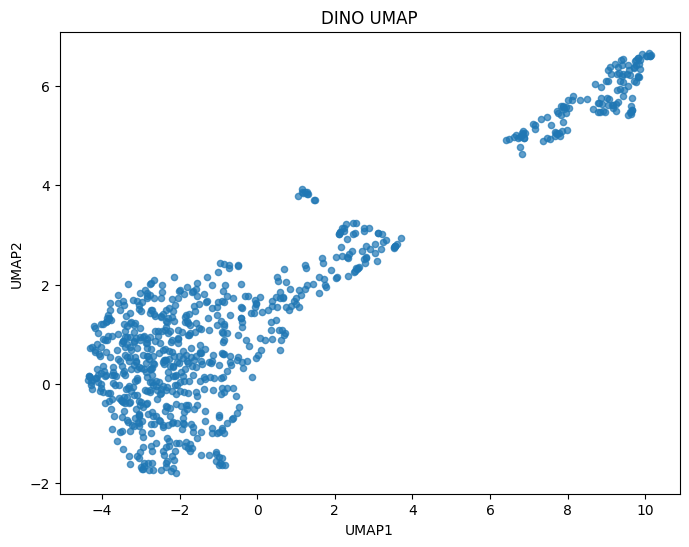

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    umap_df["UMAP1"],
    umap_df["UMAP2"],
    s=20,
    alpha=0.7
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("DINO UMAP")
plt.show()

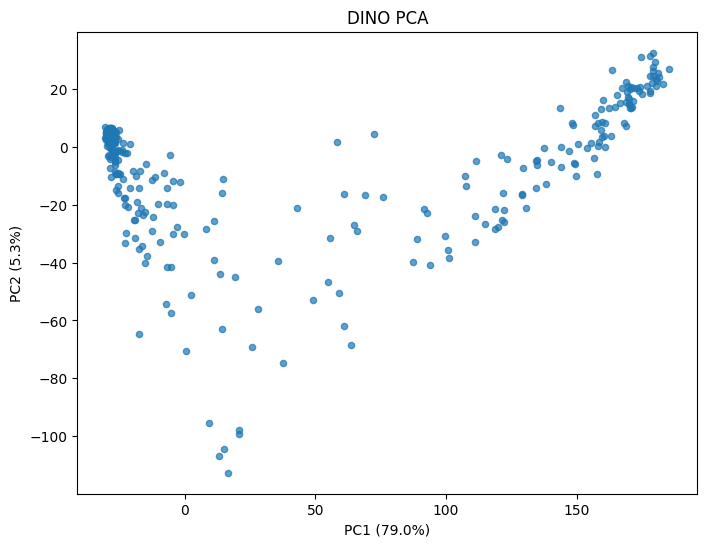

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=20,
    alpha=0.7
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)
plt.title("DINO PCA")
plt.show()

In [ ]:
# PC1은 세포독성 특성으로 보임. 너무 큰 portion을 차지하고 있음-세부적인 특징을 잡아내지 못할것.

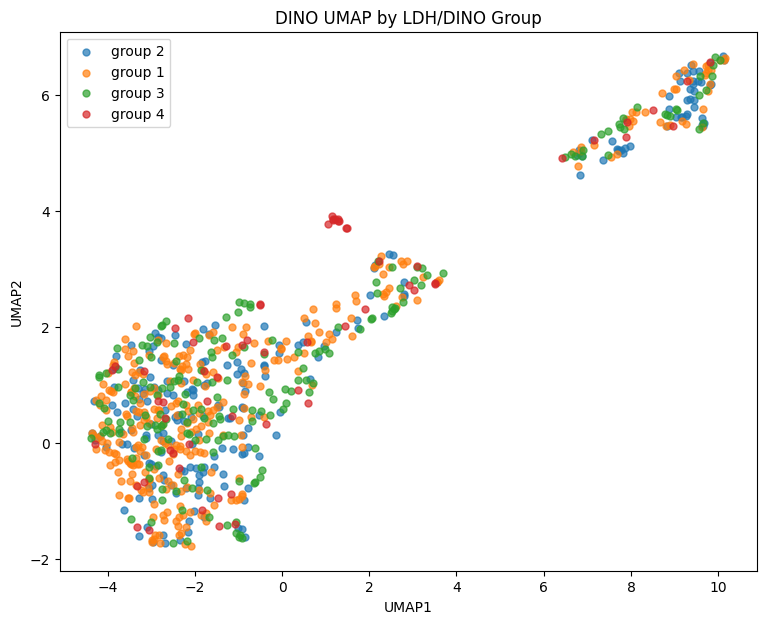

In [ ]:
groups = umap_df["Group (LDH/DINO)"].unique()

plt.figure(figsize=(9, 7))

for group in groups:
    mask = umap_df["Group (LDH/DINO)"] == group

    plt.scatter(
        umap_df.loc[mask, "UMAP1"],
        umap_df.loc[mask, "UMAP2"],
        s=25,
        alpha=0.7,
        label=group
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("DINO UMAP by LDH/DINO Group")
plt.legend()
plt.show()

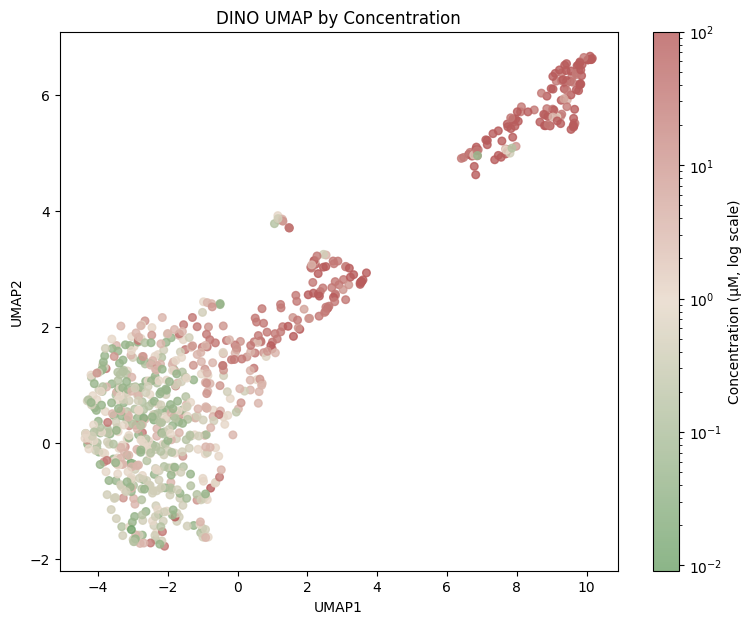

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm

conc_cmap = LinearSegmentedColormap.from_list(
    "conc_gradient",
    [
        "#6FA36B",  # low: muted green
        "#E7D8C9",  # middle: beige
        "#B85C5C"   # high: muted red
    ]
)

conc = umap_df["Metadata_Concentration"]

norm = LogNorm(
    vmin=conc[conc > 0].min(),
    vmax=conc.max()
)

plt.figure(figsize=(9, 7))

sc = plt.scatter(
    umap_df["UMAP1"],
    umap_df["UMAP2"],
    c=conc,
    cmap=conc_cmap,
    norm=norm,
    s=30,
    alpha=0.8
)

cbar = plt.colorbar(sc)
cbar.set_label("Concentration (µM, log scale)")

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("DINO UMAP by Concentration")

plt.show()

In [ ]:
# 너무 세포독성이 강한 애들이 있으면 umap이나 pca에서 너무 지배적인 특성이 됨.

In [ ]:
# IC10 기준으로 낮은애들만 pca 해볼까?